### Connect to drive <font color="red">Run First</font>

In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data <font color="red">Run First</font>

In [ ]:
# @title
import os, shutil

dst_folder = "/content/"
src_folder = "/content/drive/MyDrive/colab-data"

files = [
    "Site_DEM_points.csv",
    "Site_DEM_points.npz",
    "Ranawana_Clean_Poly.dxf",
    "Site.csv",
    "Ranawana_Contour_Map.pdf",
    "hydrology_results.csv",
    "Ranawana_Interactive_Terrain.html",
    "Ranawana_slope_terrain.html",
    "Ranawana_CS_LS_2D.pdf",
    "Centerline_3D.csv",
    "Ranawana_3D.html",
    "cross_sections_profiles_subplot.pdf",
    "Ranawana_gabion_wall.csv",
    "Ranawana_gabion_wall_alignment.pdf",
    "Ranawana_gabion_wall_alignment.csv",
    "Ranawana_Gabion_CS.pdf",
    "Ranawana_Gabion_CS.csv",
    "Ranawana_toe_alignment.csv",
    "Gabion_BOQ_by_Segment.csv",
    "Gabion_BOQ_by_Design.csv",
    "Gabion_BOQ_Total.csv",
    "Ranawana_toe_ground.dxf",
    "gabion_front_elevation.pdf",
    "Ranawana_Gabion_Layer_Details.csv",
    "Ranawana_toe_ground.dxf"
]

for file in files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    #print(src_path, dst_path)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)   # overwrites automatically
        print(f"Downloaded (overwritten if exists): {file}")
    else:
        print(f"Missing in Drive: {file}")

Downloaded (overwritten if exists): Site_DEM_points.csv
Downloaded (overwritten if exists): Site_DEM_points.npz
Downloaded (overwritten if exists): Ranawana_Clean_Poly.dxf
Missing in Drive: Site.csv
Downloaded (overwritten if exists): Ranawana_Contour_Map.pdf
Downloaded (overwritten if exists): hydrology_results.csv
Downloaded (overwritten if exists): Ranawana_Interactive_Terrain.html
Downloaded (overwritten if exists): Ranawana_slope_terrain.html
Downloaded (overwritten if exists): Ranawana_CS_LS_2D.pdf
Downloaded (overwritten if exists): Centerline_3D.csv
Downloaded (overwritten if exists): Ranawana_3D.html
Missing in Drive: cross_sections_profiles_subplot.pdf
Missing in Drive: Ranawana_gabion_wall.csv
Missing in Drive: Ranawana_gabion_wall_alignment.pdf
Missing in Drive: Ranawana_gabion_wall_alignment.csv
Missing in Drive: Ranawana_Gabion_CS.pdf
Missing in Drive: Ranawana_Gabion_CS.csv
Downloaded (overwritten if exists): Ranawana_toe_alignment.csv
Downloaded (overwritten if exists):

In [36]:
# @title
import os
import shutil


src_folder = "/content/"
dst_folder = "/content/drive/MyDrive/colab-data"

os.makedirs(dst_folder, exist_ok=True)

for file in files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    #print(src_path, dst_path)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        print(f"Copied to Drive: {file}")
    else:
        print(f"Missing: {file}")

Copied to Drive: Site_DEM_points.csv
Copied to Drive: Site_DEM_points.npz
Copied to Drive: Ranawana_Clean_Poly.dxf
Missing: Site.csv
Copied to Drive: Ranawana_Contour_Map.pdf
Copied to Drive: hydrology_results.csv
Copied to Drive: Ranawana_Interactive_Terrain.html
Copied to Drive: Ranawana_slope_terrain.html
Copied to Drive: Ranawana_CS_LS_2D.pdf
Copied to Drive: Centerline_3D.csv
Copied to Drive: Ranawana_3D.html
Missing: cross_sections_profiles_subplot.pdf
Copied to Drive: Ranawana_gabion_wall.csv
Copied to Drive: Ranawana_gabion_wall_alignment.pdf
Copied to Drive: Ranawana_gabion_wall_alignment.csv
Missing: Ranawana_Gabion_CS.pdf
Missing: Ranawana_Gabion_CS.csv
Copied to Drive: Ranawana_toe_alignment.csv
Copied to Drive: Gabion_BOQ_by_Segment.csv
Copied to Drive: Gabion_BOQ_by_Design.csv
Copied to Drive: Gabion_BOQ_Total.csv
Copied to Drive: Ranawana_toe_ground.dxf
Missing: gabion_front_elevation.pdf
Missing: Ranawana_Gabion_Layer_Details.csv
Copied to Drive: Ranawana_toe_ground.dxf

In [ ]:
!pip install ezdxf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 38.1 MB/s eta 0:00:00


### Site DEM Grid Points

In [ ]:
# @title
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

demfile = "Site_DEM_points.csv"
data = pd.read_csv(demfile)

print(data.columns)

x = data["x"].values
y = data["y"].values
z = data["z"].values
point_id = data["id"].values if "id" in data.columns else np.arange(len(data))

valid = ~(np.isnan(x) | np.isnan(y) | np.isnan(z))

x = x[valid]
y = y[valid]
z = z[valid]
point_id = point_id[valid]

# =========================================================
# Create DEM grid
# =========================================================
grid_res = 0.5

xi = np.arange(x.min(), x.max() + grid_res, grid_res)
yi = np.arange(y.min(), y.max() + grid_res, grid_res)

Xi, Yi = np.meshgrid(xi, yi)

Zi = griddata(
    (x, y),
    z,
    (Xi, Yi),
    method="linear"
)

Zi_nearest = griddata(
    (x, y),
    z,
    (Xi, Yi),
    method="nearest"
)

Zi = np.where(np.isnan(Zi), Zi_nearest, Zi)

# =========================================================
# Create 1 m contour levels
# =========================================================
z_min = np.floor(np.nanmin(Zi))
z_max = np.ceil(np.nanmax(Zi))

levels = np.arange(z_min, z_max + 1, 1)

print("Grid shape:", Zi.shape)
print("Elevation:", z_min, "to", z_max, "=", z_max - z_min, "m")
print("Levels:", levels)
print("Loaded points:", len(x))

Index(['id', 'y', 'x', 'z', 'type', 'dist'], dtype='object')
Grid shape: (139, 120)
Elevation: 99.0 to 122.0 = 23.0 m
Levels: [ 99. 100. 101. 102. 103. 104. 105. 106. 107. 108. 109. 110. 111. 112.
 113. 114. 115. 116. 117. 118. 119. 120. 121. 122.]
Loaded points: 283


Countours and Infrastructure

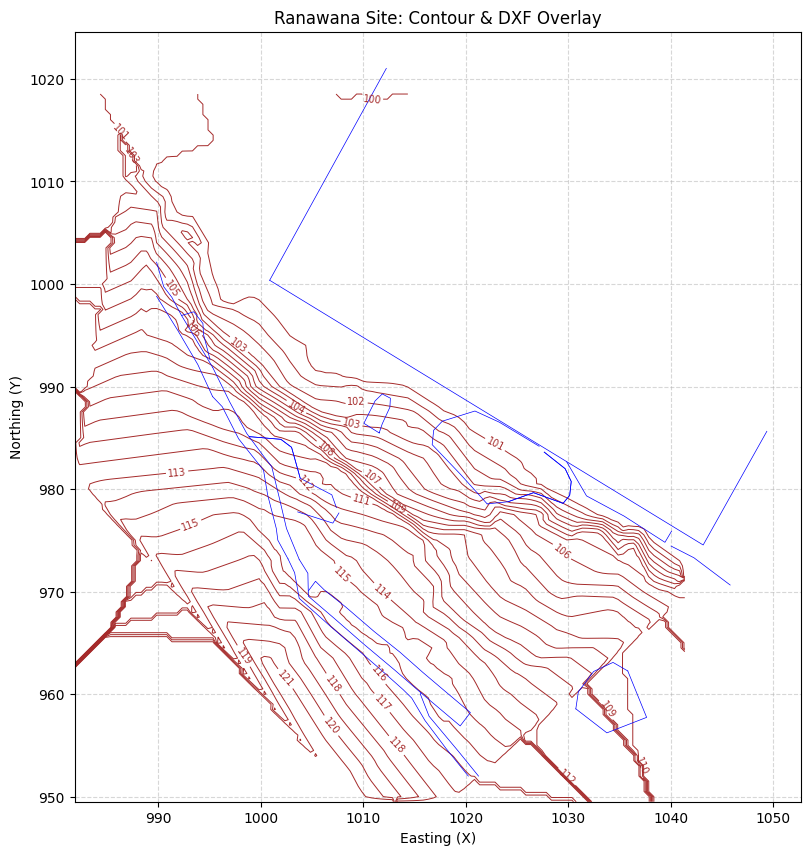

In [ ]:
# @title
import ezdxf
import matplotlib.pyplot as plt
import numpy as np

def plot_dxf_on_contour_fit(
    dxf_file,
    Xi, Yi, Zi,
    levels=20,
    show_labels=False,
    preserve_aspect=False,
    x_offset=0.0,
    y_offset=0.0,
    line_color="blue",
    line_width=0.5
):
    # 1. Read DXF
    try:
        doc = ezdxf.readfile(dxf_file)
        msp = doc.modelspace()
    except Exception as e:
        print(f"Error reading DXF: {e}")
        return []

    # 2. Collect entities and bounding box
    entities = []
    all_x = []
    all_y = []

    for e in msp:
        etype = e.dxftype()

        if etype == "LWPOLYLINE":
            pts = [(p[0], p[1]) for p in e.get_points()]
            entities.append(("LWPOLYLINE", pts, e.closed))
            all_x.extend([p[0] for p in pts])
            all_y.extend([p[1] for p in pts])

        elif etype == "POLYLINE":
            pts = [(v.dxf.location.x, v.dxf.location.y) for v in e.vertices]
            is_closed = e.is_closed if hasattr(e, 'is_closed') else False
            entities.append(("POLYLINE", pts, is_closed))
            all_x.extend([p[0] for p in pts])
            all_y.extend([p[1] for p in pts])

        elif etype in ["TEXT", "MTEXT"]:
            try:
                # Handle different text insertion point attributes
                ins = e.dxf.insert
                txt = e.dxf.text if etype == "TEXT" else e.text
                entities.append(("TEXT", (ins.x, ins.y, txt), False))
                all_x.append(ins.x)
                all_y.append(ins.y)
            except:
                continue

    if not all_x or not all_y:
        print("No DXF geometry found.")
        return []

    # 3. Calculate Bounding Boxes and Scaling
    dxf_xmin, dxf_xmax = min(all_x), max(all_x)
    dxf_ymin, dxf_ymax = min(all_y), max(all_y)

    ctr_xmin, ctr_xmax = np.nanmin(Xi), np.nanmax(Xi)
    ctr_ymin, ctr_ymax = np.nanmin(Yi), np.nanmax(Yi)

    dxf_w = max(dxf_xmax - dxf_xmin, 1e-6)
    dxf_h = max(dxf_ymax - dxf_ymin, 1e-6)
    ctr_w = ctr_xmax - ctr_xmin
    ctr_h = ctr_ymax - ctr_ymin

    sx = ctr_w / dxf_w
    sy = ctr_h / dxf_h

    if preserve_aspect:
        s = min(sx, sy)
        sx = sy = s
    return entities, (dxf_xmin, dxf_ymin), (sx, sy), (ctr_xmin, ctr_ymin)


    # 4. Define Transform Function (Moved inside to access local scale variables)
    def transform_xy(x, y):
        xt = ctr_xmin + (x - dxf_xmin) * sx
        yt = ctr_ymin + (y - dxf_ymin) * sy

        if preserve_aspect:
            # Center the DXF in the contour bounds if aspect is preserved
            xt += (ctr_w - (dxf_w * sx)) / 2.0
            yt += (ctr_h - (dxf_h * sy)) / 2.0

        return xt + x_offset, yt + y_offset

    # 5. Plot DXF entities onto the existing Matplotlib axes
    for kind, data, closed in entities:
        if kind in ["LWPOLYLINE", "POLYLINE"]:
            xs_t, ys_t = [], []
            for x, y in data:
                xt, yt = transform_xy(x, y)
                xs_t.append(xt)
                ys_t.append(yt)

            if closed and len(xs_t) > 0:
                xs_t.append(xs_t[0])
                ys_t.append(ys_t[0])

            plt.plot(xs_t, ys_t, color=line_color, linewidth=line_width)

        elif kind == "TEXT" and show_labels:
            x, y, txt = data
            xt, yt = transform_xy(x, y)
            plt.text(xt, yt, txt, fontsize=6, color="black", alpha=0.7)

    print(f"DXF Overlay Complete. Scale: {sx:.4f}x, {sy:.4f}y")
    return entities

# ============================================================
# EXECUTION
# ============================================================

plt.figure(figsize=(10, 10))

# 1. Plot Contours
levels = np.linspace(np.nanmin(Zi), np.nanmax(Zi), 30)
cs = plt.contour(Xi, Yi, Zi, levels=levels, colors="brown", linewidths=0.7)
plt.clabel(cs, inline=True, fontsize=7, fmt="%.0f")

# 2. Plot DXF and get entities back
# Adjust x_offset and y_offset based on your site alignment
dxf_entities, (dxf_xmin, dxf_ymin), (sx, sy), (ctr_xmin, ctr_ymin)= plot_dxf_on_contour_fit(
    dxf_file="Ranawana_Clean_Poly.dxf", # replace with your variable
    Xi=Xi, Yi=Yi, Zi=Zi,
    show_labels=True,
    preserve_aspect=False,
    x_offset=8.0,
    y_offset=2.5,
    line_color="blue",
    line_width=0.8
)

# Loop through entities (etype, pts, is_closed)
for _, pts, is_closed in dxf_entities:
    pts_arr = np.array(pts)

    # 1. Apply Transformation
    tx = (pts_arr[:, 0] - dxf_xmin) * sx + ctr_xmin + 8
    ty = (pts_arr[:, 1] - dxf_ymin) * sy + ctr_ymin + 2.5

    # 2. Handle Closing
    if is_closed:
        tx = np.append(tx, tx[0])
        ty = np.append(ty, ty[0])

    # 3. Plot
    plt.plot(tx, ty, color='blue', linewidth=0.5)



# 3. Final Formatting
plt.gca().set_aspect("equal")
plt.xlabel("Easting (X)")
plt.ylabel("Northing (Y)")
plt.title("Ranawana Site: Contour & DXF Overlay")
plt.grid(True, linestyle='--', alpha=0.5)

# Save and Show
plt.savefig("Ranawana_Contour_Map.pdf", format='pdf', bbox_inches='tight')
plt.show()

3D View by Slope Gradients

In [ ]:
# @title
import plotly.graph_objects as go
import numpy as np

# grid spacing
dx = float(Xi[0, 1] - Xi[0, 0])
dy = float(Yi[1, 0] - Yi[0, 0])

# gradients (correct order)
dz_dy, dz_dx = np.gradient(Zi, dy, dx)

# slope
slope_deg = np.degrees(
    np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
)

print("Slope min:", np.nanmin(slope_deg))
print("Slope max:", np.nanmax(slope_deg))

fig = go.Figure()

fig.add_trace(go.Surface(
    x=Xi,
    y=Yi,
    z=Zi,
    surfacecolor=slope_deg,
    colorscale="YlOrRd",
    cmin=0,
    cmax=np.nanmax(slope_deg),
    opacity=0.95,
    showscale=True,
    colorbar=dict(title="Slope (deg)"),
    contours={
        "z": {
            "show": True,
            "start": float(np.floor(np.nanmin(Zi))),
            "end": float(np.ceil(np.nanmax(Zi))),
            "size": 1,
            "color": "brown",
            "width": 2
        }
    },
    hovertemplate=(
        "X: %{x:.2f}<br>"
        "Y: %{y:.2f}<br>"
        "Z: %{z:.2f}<br>"
        "Slope: %{surfacecolor:.2f}°<extra></extra>"
    )
))

fig.update_layout(
    title="3D Terrain Colored by Slope",
    width=1100,
    height=850,
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Elevation (m)",
        aspectmode="data",
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8))
    )
)

fig.write_html("Ranawana_slope_terrain.html")
fig.show()

Slope min: 0.0
Slope max: 86.89903960695244


Gabion Toe Wall

In [ ]:
# @title
# =========================================================
# HYBRID VERSION
# Keeps your current calling style:
#   result = design_gabion_toe_wall_from_dem(...)
#   plot_best_gabion_alignment(...)
# But uses smoother selected line + refined wall geometry
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from scipy.interpolate import griddata
from shapely.geometry import Point, LineString, MultiLineString


def trim_line_between_points(line, xy1, xy2):
    """
    Trim a LineString between two nearest points to xy1 and xy2
    """
    if line is None:
        return None

    # ensure LineString
    if not isinstance(line, LineString):
        line = LineString(line)

    p1 = Point(xy1)
    p2 = Point(xy2)

    # project to line (distance along line)
    d1 = line.project(p1)
    d2 = line.project(p2)

    # sort distances
    d_start, d_end = sorted([d1, d2])

    # extract segment
    distances = np.linspace(d_start, d_end, int((d_end - d_start) / 0.5) + 2)
    pts = [line.interpolate(d) for d in distances]

    trimmed = LineString([(p.x, p.y) for p in pts])
    return trimmed

# =========================================================
# 1. BASIC HELPERS
# =========================================================

def to_xy_array(line):
    if line is None:
        return None

    if hasattr(line, "geom_type"):
        if line.geom_type == "LineString":
            arr = np.array(line.coords, dtype=float)
            return arr[:, :2]
        elif line.geom_type == "MultiLineString":
            parts = [np.array(g.coords, dtype=float)[:, :2] for g in line.geoms if len(g.coords) >= 2]
            if not parts:
                return None
            lengths = [line_length_xy(p) for p in parts]
            return parts[int(np.argmax(lengths))]

    if hasattr(line, "coords"):
        arr = np.array(line.coords, dtype=float)
        return arr[:, :2]

    arr = np.asarray(line, dtype=float)
    if arr.ndim == 2 and arr.shape[1] >= 2:
        return arr[:, :2]

    return None


def line_length_xy(line):
    line = to_xy_array(line)
    if line is None or len(line) < 2:
        return 0.0
    d = np.sqrt(np.sum(np.diff(line, axis=0)**2, axis=1))
    return float(np.sum(d))


def get_grid_spacing(Xi, Yi):
    dx = float(np.mean(np.abs(np.diff(Xi[0, :]))))
    dy = float(np.mean(np.abs(np.diff(Yi[:, 0]))))
    return dx, dy


def compute_slope_grid(Xi, Yi, Zi):
    dx, dy = get_grid_spacing(Xi, Yi)

    # Correct order
    dz_dy, dz_dx = np.gradient(Zi, dy, dx)

    slope = np.sqrt(dz_dx**2 + dz_dy**2)
    slope_deg = np.degrees(np.arctan(slope))

    return slope_deg

def sample_grid_values_along_line(line, Xi, Yi, grid, method="linear"):
    line = to_xy_array(line)

    if line is None or len(line) == 0:
        return np.array([])

    x_flat = Xi.ravel()
    y_flat = Yi.ravel()
    g_flat = grid.ravel()

    valid = ~np.isnan(g_flat)

    vals = griddata(
        (x_flat[valid], y_flat[valid]),
        g_flat[valid],
        (line[:, 0], line[:, 1]),
        method=method
    )

    # fallback using nearest
    nan_mask = np.isnan(vals)

    if np.any(nan_mask):
        vals[nan_mask] = griddata(
            (x_flat[valid], y_flat[valid]),
            g_flat[valid],
            (line[nan_mask, 0], line[nan_mask, 1]),
            method="nearest"
        )

    return vals


def sample_z_along_line(line, Xi, Yi, Zi):
    return sample_grid_values_along_line(
        line,
        Xi,
        Yi,
        Zi,
        method="linear"
    )


# =========================================================
# 2. SHAPELY / SMOOTHING HELPERS
# =========================================================

def orient_line_left_to_right(line):
    coords = to_xy_array(line)
    if coords is None or len(coords) < 2:
        return None
    if coords[0, 0] > coords[-1, 0]:
        coords = coords[::-1]
    return LineString(coords)


def smooth_linestring(line, smoothing=1.0, n_points=300):
    """
    Gentle spline smoothing for the selected best line
    """
    coords = to_xy_array(line)
    if coords is None or len(coords) < 4:
        return LineString(coords) if coords is not None else None

    x = coords[:, 0]
    y = coords[:, 1]

    keep = [0]
    for i in range(1, len(coords)):
        if np.hypot(x[i] - x[keep[-1]], y[i] - y[keep[-1]]) > 1e-6:
            keep.append(i)

    x = x[keep]
    y = y[keep]

    if len(x) < 4:
        return LineString(np.column_stack([x, y]))

    try:
        tck, u = splprep([x, y], s=smoothing)
        u_new = np.linspace(0, 1, n_points)
        x_new, y_new = splev(u_new, tck)
        return LineString(np.column_stack([x_new, y_new]))
    except Exception:
        return LineString(np.column_stack([x, y]))


def offset_line(line, distance, side='right'):
    try:
        off = line.parallel_offset(distance, side=side, join_style=2)
        if off.is_empty:
            return None
        if isinstance(off, MultiLineString):
            off = max(off.geoms, key=lambda g: g.length)
        return LineString(off.coords)
    except Exception:
        return None


def sample_line_by_spacing(line, spacing=2.0):
    n = max(2, int(line.length / spacing) + 1)
    distances = np.linspace(0, line.length, n)
    pts = [line.interpolate(d) for d in distances]
    return np.array([[p.x, p.y] for p in pts])


# =========================================================
# 3. CONTOUR EXTRACTION
# =========================================================

def extract_contour_lines(Xi, Yi, Zi, level):
    fig, ax = plt.subplots()
    cs = ax.contour(Xi, Yi, Zi, levels=[level])
    plt.close(fig)

    lines = []
    if len(cs.allsegs) > 0:
        for seg in cs.allsegs[0]:
            if seg is not None and len(seg) >= 2:
                try:
                    lines.append(LineString(np.array(seg)[:, :2]))
                except Exception:
                    continue
    return lines


def extract_contour_lines_for_levels(Xi, Yi, Zi, levels):
    candidates = []
    for lvl in levels:
        lines = extract_contour_lines(Xi, Yi, Zi, lvl)
        for ln in lines:
            candidates.append({
                "level": float(lvl),
                "line": ln
            })
    return candidates


# =========================================================
# 4. SCORING
# =========================================================

def compute_curvature_score(line):
    coords = to_xy_array(line)
    if coords is None or len(coords) < 3:
        return 999.0

    v1 = coords[1:-1] - coords[:-2]
    v2 = coords[2:] - coords[1:-1]

    n1 = np.linalg.norm(v1, axis=1)
    n2 = np.linalg.norm(v2, axis=1)
    valid = (n1 > 1e-9) & (n2 > 1e-9)

    if np.sum(valid) == 0:
        return 999.0

    v1 = v1[valid]
    v2 = v2[valid]
    n1 = n1[valid]
    n2 = n2[valid]

    cosang = np.sum(v1 * v2, axis=1) / (n1 * n2)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang = np.degrees(np.arccos(cosang))
    return float(np.mean(np.abs(ang)))


def normalize_series(values, inverse=False):
    arr = np.array(values, dtype=float)

    if len(arr) == 0:
        return arr

    arr = np.nan_to_num(arr, nan=np.nanmax(arr))

    amin = np.nanmin(arr)
    amax = np.nanmax(arr)

    if np.isclose(amax, amin):
        norm = np.ones_like(arr)
    else:
        norm = (arr - amin) / (amax - amin)

    return 1.0 - norm if inverse else norm

def score_candidate_lines(
    candidates,
    Xi, Yi, Zi,
    target_level=100.5,
    min_length=8.0,
    smoothing=2.0,
    preferred_x=None,
    preferred_y=None,
    weight_length=0.35,
    weight_level=0.20,
    weight_curvature=0.25,
    weight_slope=0.20
):
    slope_grid = compute_slope_grid(Xi, Yi, Zi)
    results = []

    for item in candidates:
        level = float(item["level"])
        raw_line = item["line"]

        if raw_line is None or raw_line.length < min_length:
            continue

        line = orient_line_left_to_right(raw_line)
        smooth_line = smooth_linestring(line, smoothing=smoothing, n_points=300)

        L = smooth_line.length
        if L < min_length:
            continue

        line_xy = to_xy_array(smooth_line)
        zs = sample_z_along_line(line_xy, Xi, Yi, Zi)
        if len(zs) == 0 or np.all(np.isnan(zs)):
            continue

        z_mean = float(np.nanmean(zs))
        z_std = float(np.nanstd(zs))
        level_error = abs(z_mean - target_level)

        slopes = sample_grid_values_along_line(line_xy, Xi, Yi, slope_grid)
        mean_slope = float(np.nanmean(slopes)) if len(slopes) > 0 else 90.0
        curvature = compute_curvature_score(line_xy)

        if np.isnan(mean_slope):
          mean_slope = 90.0

        zone_bonus = 0.0
        xm = np.nanmean(line_xy[:, 0])
        ym = np.nanmean(line_xy[:, 1])

        if preferred_x is not None:
            xmin, xmax = preferred_x
            if xmin <= xm <= xmax:
                zone_bonus += 0.5

        if preferred_y is not None:
            ymin, ymax = preferred_y
            if ymin <= ym <= ymax:
                zone_bonus += 0.5

        results.append({
            "level": level,
            "line": raw_line,
            "smooth_line": smooth_line,
            "length_m": L,
            "z_mean": z_mean,
            "z_std": z_std,
            "level_error": level_error,
            "mean_slope_deg": mean_slope,
            "curvature_deg": curvature,
            "zone_bonus": zone_bonus
        })

    if len(results) == 0:
        return []

    lengths = [r["length_m"] for r in results]
    level_errors = [r["level_error"] for r in results]
    curvatures = [r["curvature_deg"] for r in results]
    slopes = [r["mean_slope_deg"] for r in results]

    length_score = normalize_series(lengths, inverse=False)
    level_score = normalize_series(level_errors, inverse=True)
    curve_score = normalize_series(curvatures, inverse=True)
    slope_score = normalize_series(slopes, inverse=True)

    for i, r in enumerate(results):
        total = (
            weight_length * length_score[i] +
            weight_level * level_score[i] +
            weight_curvature * curve_score[i] +
            weight_slope * slope_score[i] +
            0.05 * r["zone_bonus"]
        )
        r["score"] = float(total)

    results = sorted(results, key=lambda x: x["score"], reverse=True)
    return results


# =========================================================
# 5. MAIN FUNCTION
# =========================================================

def design_gabion_toe_wall_from_dem(
    Xi, Yi, Zi,
    target_level=100.5,
    level_tolerance=0.5,
    level_step=0.1,
    smoothing=2.0,
    resample_spacing=0.5,   # kept for compatibility
    min_length=8.0,
    preferred_x=None,
    preferred_y=None,
    offset_side='right'
):
    levels = np.arange(
        target_level - level_tolerance,
        target_level + level_tolerance + 1e-9,
        level_step
    )

    candidates = extract_contour_lines_for_levels(Xi, Yi, Zi, levels)

    ranked = score_candidate_lines(
        candidates,
        Xi, Yi, Zi,
        target_level=target_level,
        min_length=min_length,
        smoothing=smoothing,
        preferred_x=preferred_x,
        preferred_y=preferred_y
    )

    if len(ranked) == 0:
      return {
          "best_line": None,
          "best_result": None,
          "ranked_results": [],
          "wall_geom": {},
          "summary": "No suitable contour line found."
      }

    best = ranked[0]
    best_smooth = best["smooth_line"]

    rear_edge_line = orient_line_left_to_right(best_smooth)
    front_edge_base = offset_line(rear_edge_line, 2.0, side=offset_side)
    front_edge_top = offset_line(rear_edge_line, 1.0, side=offset_side)
    drain_pipe_line = offset_line(rear_edge_line, 0.30, side=offset_side)
    module_points = sample_line_by_spacing(rear_edge_line, spacing=2.0)

    wall_geom = {
        "rear_edge_line": rear_edge_line,
        "front_edge_base": front_edge_base,
        "front_edge_top": front_edge_top,
        "drain_pipe_line": drain_pipe_line,
        "module_points": module_points
    }

    return {
        "best_line": to_xy_array(rear_edge_line),
        "best_result": best,
        "ranked_results": ranked,
        "wall_geom": wall_geom,
        "summary": f"Best gabion wall line selected near {best['z_mean']:.2f} m with score {best['score']:.3f}"
    }


# =========================================================
# 6. CHAINAGE
# =========================================================

def create_chainage_points_from_linestring(line, interval=2.0):
    pts = sample_line_by_spacing(line, spacing=interval)
    if pts is None or len(pts) < 2:
        return None

    seg = np.sqrt(np.sum(np.diff(pts, axis=0)**2, axis=1))
    chain = np.insert(np.cumsum(seg), 0, 0.0)
    return np.column_stack([chain, pts[:, 0], pts[:, 1]])

def plot_best_gabion_alignment(
    Xi, Yi, Zi,
    result,
    levels=30,
    show_top_n=5,
    show_chainage=True,
    chain_interval=2.0,
    figsize=(10, 8)
):
    ranked = result["ranked_results"]
    best = result["best_result"]
    wall_geom = result.get("wall_geom", {})
    best_line = to_xy_array(result["best_line"])

    # terrain style closer to your later plot
    cs = plt.contour(Xi, Yi, Zi, levels=levels, colors="brown", linewidths=0.6)
    plt.clabel(cs, inline=True, fontsize=7, fmt="%.1f")

    nshow = min(show_top_n, len(ranked))
    for i in range(nshow):
        line = to_xy_array(ranked[i]["smooth_line"])
        if line is not None:
            plt.plot(
                line[:, 0], line[:, 1],
                linestyle="--",
                linewidth=1.0,
                alpha=0.7,
                label=f"Candidate {i+1}"
            )

    # refined wall geometry
    rear = wall_geom.get("rear_edge_line", None)
    fb = wall_geom.get("front_edge_base", None)
    ft = wall_geom.get("front_edge_top", None)
    dp = wall_geom.get("drain_pipe_line", None)

    if rear is not None:
        rear_xy = np.array(rear.coords)
        plt.plot(rear_xy[:, 0], rear_xy[:, 1], 'k-', linewidth=1, label="Rear Edge / Toe Alignment")

    if fb is not None:
        fb_xy = np.array(fb.coords)
        plt.plot(fb_xy[:, 0], fb_xy[:, 1], 'r--', linewidth=1.3, label="Front Edge Base (2 m)")

    if ft is not None:
        ft_xy = np.array(ft.coords)
        plt.plot(ft_xy[:, 0], ft_xy[:, 1], 'b--', linewidth=1.1, label="Front Edge Top (1 m)")

    if dp is not None:
        dp_xy = np.array(dp.coords)
        plt.plot(dp_xy[:, 0], dp_xy[:, 1], color="cyan", linewidth=1.0, label="Drain Pipe")

    if best_line is not None:
        mid = len(best_line) // 2
        plt.text(
            best_line[mid, 0],
            best_line[mid, 1],
            f"Z~{best['z_mean']:.2f} m",
            fontsize=8,
            color="black",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
        )

    if show_chainage and rear is not None:
        chain_pts = create_chainage_points_from_linestring(rear, interval=chain_interval)
        if chain_pts is not None:
            plt.scatter(chain_pts[:, 1], chain_pts[:, 2], c="black", s=10, label="2 m Module Points")
            for i, row in enumerate(chain_pts):
                ch, x, y = row
                if i % 2 == 0:
                    plt.text(x, y, f"{ch:.0f}", fontsize=6, color="black")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Gabion Toe Wall Alignment")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

def plot_dxf_fit_to_dem(
    dxf_file,
    Xi,
    Yi,
    Zi=None,
    ax=None,
    x_offset=0.0,
    y_offset=0.0,
    scale=1.0,
    line_color="blue",
    linewidth=0.7,
    alpha=0.8,
    fill=False,
    fill_alpha=0.15,
    fill_color=None,
    preserve_aspect=True,
    show_labels=False,
    label_prefix="DXF",
    label_fontsize=7,
    return_entities=False
):
    """
    Plot DXF entities fitted to DEM coordinate space.

    Supports:
    - LWPOLYLINE
    - POLYLINE
    - LINE

    Notes:
    - Zi is optional because only Xi and Yi are needed for fitting.
    - fill=True works mainly for closed polylines.
    """

    import ezdxf
    import numpy as np
    import matplotlib.pyplot as plt

    if ax is None:
        ax = plt.gca()

    if fill_color is None:
        fill_color = line_color

    doc = ezdxf.readfile(dxf_file)
    msp = doc.modelspace()

    raw_entities = []
    all_x, all_y = [], []

    # -------------------------------------------------
    # Read DXF entities
    # -------------------------------------------------
    for e in msp:
        pts = []
        closed = False

        if e.dxftype() == "LWPOLYLINE":
            pts = [(p[0], p[1]) for p in e.get_points()]
            closed = bool(e.closed)

        elif e.dxftype() == "POLYLINE":
            pts = [(v.dxf.location.x, v.dxf.location.y) for v in e.vertices]
            closed = bool(e.is_closed)

        elif e.dxftype() == "LINE":
            pts = [
                (e.dxf.start.x, e.dxf.start.y),
                (e.dxf.end.x, e.dxf.end.y)
            ]
            closed = False

        if len(pts) >= 2:
            pts = np.array(pts, dtype=float)

            raw_entities.append({
                "type": e.dxftype(),
                "points": pts,
                "closed": closed,
                "layer": getattr(e.dxf, "layer", "")
            })

            all_x.extend(pts[:, 0])
            all_y.extend(pts[:, 1])

    if not raw_entities:
        raise ValueError("No supported DXF entities found.")

    all_x = np.array(all_x)
    all_y = np.array(all_y)

    # -------------------------------------------------
    # DXF extent
    # -------------------------------------------------
    dxf_xmin, dxf_xmax = np.nanmin(all_x), np.nanmax(all_x)
    dxf_ymin, dxf_ymax = np.nanmin(all_y), np.nanmax(all_y)

    dxf_width = dxf_xmax - dxf_xmin
    dxf_height = dxf_ymax - dxf_ymin

    if dxf_width == 0 or dxf_height == 0:
        raise ValueError("DXF has zero width or height.")

    # -------------------------------------------------
    # DEM extent
    # -------------------------------------------------
    dem_xmin, dem_xmax = np.nanmin(Xi), np.nanmax(Xi)
    dem_ymin, dem_ymax = np.nanmin(Yi), np.nanmax(Yi)

    dem_width = dem_xmax - dem_xmin
    dem_height = dem_ymax - dem_ymin

    # -------------------------------------------------
    # Scaling
    # -------------------------------------------------
    if preserve_aspect:
        sx = sy = min(dem_width / dxf_width, dem_height / dxf_height) * scale
    else:
        sx = (dem_width / dxf_width) * scale
        sy = (dem_height / dxf_height) * scale

    # -------------------------------------------------
    # Centre alignment
    # -------------------------------------------------
    dxf_cx = (dxf_xmin + dxf_xmax) / 2
    dxf_cy = (dxf_ymin + dxf_ymax) / 2

    dem_cx = (dem_xmin + dem_xmax) / 2 + x_offset
    dem_cy = (dem_ymin + dem_ymax) / 2 + y_offset

    fitted_entities = []

    # -------------------------------------------------
    # Transform and plot
    # -------------------------------------------------
    for i, ent in enumerate(raw_entities):

        pts = ent["points"]

        x_fit = (pts[:, 0] - dxf_cx) * sx + dem_cx
        y_fit = (pts[:, 1] - dxf_cy) * sy + dem_cy

        fitted = np.column_stack([x_fit, y_fit])

        ax.plot(
            x_fit,
            y_fit,
            color=line_color,
            linewidth=linewidth,
            alpha=alpha
        )

        if fill and ent["closed"] and len(fitted) >= 3:
            ax.fill(
                x_fit,
                y_fit,
                color=fill_color,
                alpha=fill_alpha
            )

        if show_labels:
            mid = len(fitted) // 2
            ax.text(
                fitted[mid, 0],
                fitted[mid, 1],
                f"{label_prefix}{i+1}",
                fontsize=label_fontsize,
                color=line_color
            )

        fitted_entities.append({
            "type": ent["type"],
            "layer": ent["layer"],
            "closed": ent["closed"],
            "points": fitted
        })

    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.3)

    if return_entities:
        return fitted_entities

Gabion Wall Condidates

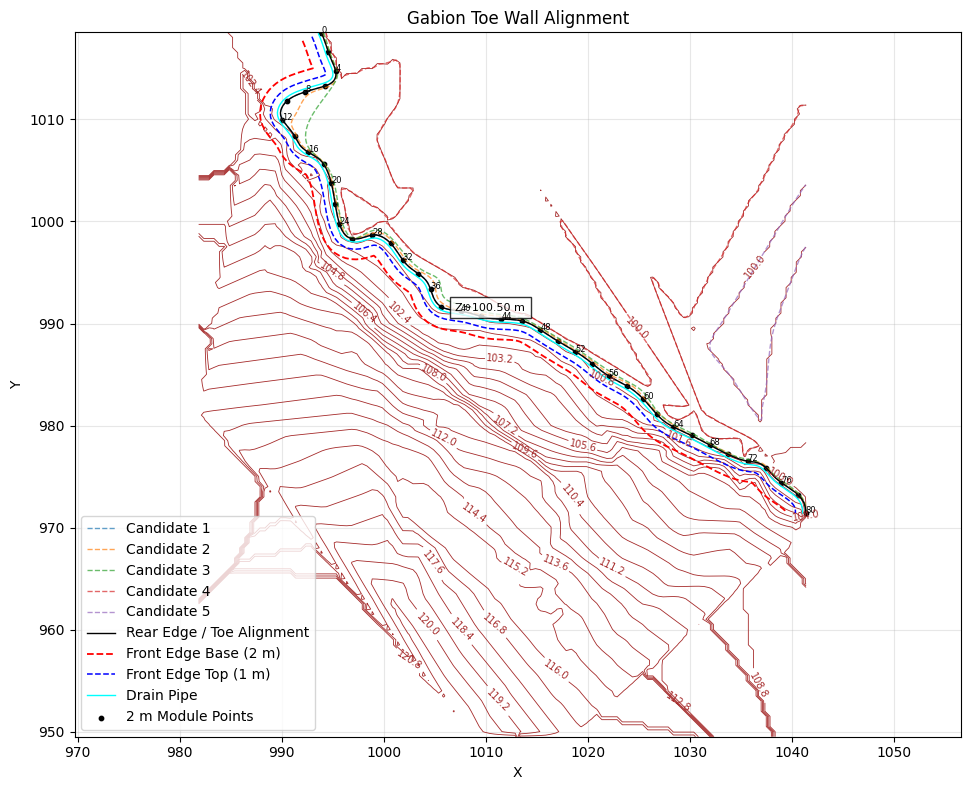

Candidate 1: Score=0.5865, Mean_Z=100.50, Length=80.88 m, Curvature=2.93, Slope=34.26
Candidate 2: Score=0.5513, Mean_Z=100.41, Length=79.68 m, Curvature=3.04, Slope=33.02
Candidate 3: Score=0.5289, Mean_Z=100.31, Length=77.53 m, Curvature=2.65, Slope=30.99
Candidate 4: Score=0.5263, Mean_Z=100.00, Length=180.34 m, Curvature=11.41, Slope=8.92


In [ ]:
result = design_gabion_toe_wall_from_dem(
    Xi, Yi, Zi,
    target_level=100.5,
    level_tolerance=0.5,
    level_step=0.1,
    smoothing=2.0,
    resample_spacing=0.5,
    min_length=8.0
)

plt.figure(figsize=(10, 8))

plot_best_gabion_alignment(
    Xi, Yi, Zi,
    result,
    levels=30,
    show_top_n=5,
    show_chainage=True,
    chain_interval=2.0
)

# only if your DXF function does NOT require ax
plot_dxf_on_contour_fit(
    "Ranawana_Clean_Poly.dxf",
    Xi, Yi, Zi,
    x_offset=8,
    y_offset=2.5,
    line_color="red",
    line_width=0.5
)

plt.gca().set_aspect("equal", adjustable="box")
plt.grid(True, alpha=0.3)

plt.savefig(
    "gabion_wall_alignment.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

# @title
for i, r in enumerate(result["ranked_results"][:4], start=1):
    print(
        f"Candidate {i}: "
        f"Score={r['score']:.4f}, "
        f"Mean_Z={r['z_mean']:.2f}, "
        f"Length={r['length_m']:.2f} m, "
        f"Curvature={r['curvature_deg']:.2f}, "
        f"Slope={r['mean_slope_deg']:.2f}"
    )

Trimmed gabion wall

Best gabion wall line selected near 100.50 m with score 0.586
Trimmed gabion wall length: 68.44 m
Saved: Ranawana_gabion_wall_alignment.csv


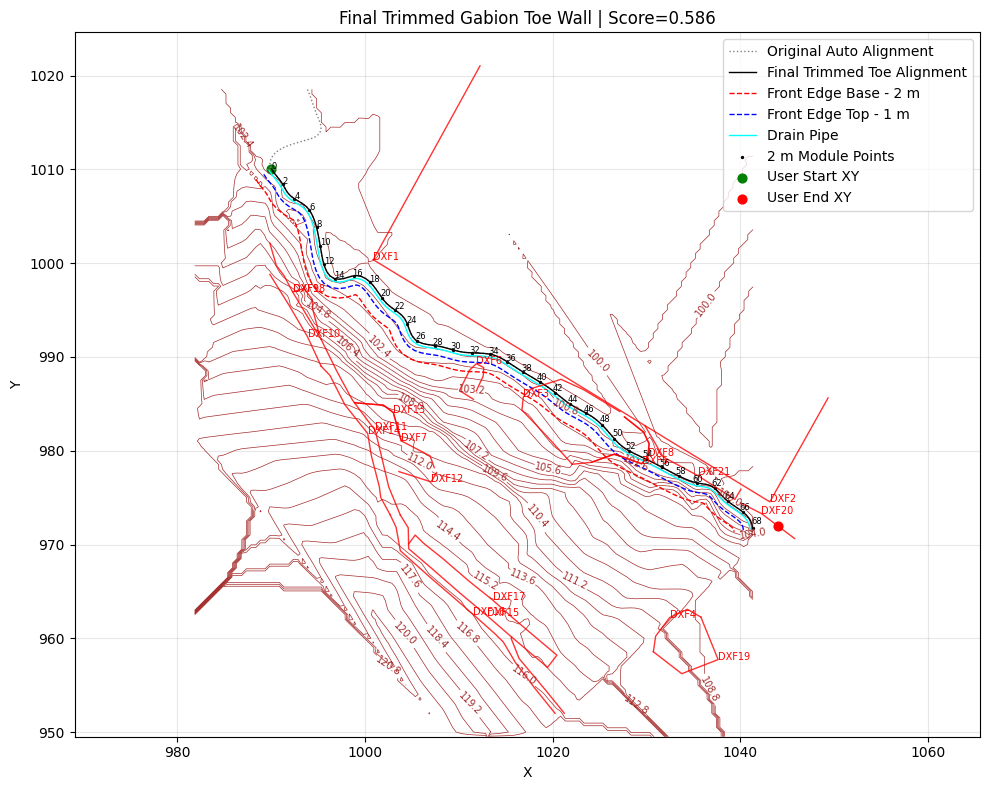

Saved: Ranawana_gabion_wall.pdf


In [ ]:
# @title
# =========================================================
# 1. USER INPUTS
# =========================================================

# Approximate gabion wall start/end points
xy1 = (990, 1010)   # start point - change this
xy2 = (1044, 972)   # end point - change this

target_level = 100.5
level_tolerance = 0.5
level_step = 0.1

offset_side = "right"   # try "left" if wall offsets wrong direction

dxf_file = "Ranawana_Clean_Poly.dxf"

# =========================================================
# 2. RUN AUTO GABION DESIGN
# =========================================================

result = design_gabion_toe_wall_from_dem(
    Xi, Yi, Zi,
    target_level=target_level,
    level_tolerance=level_tolerance,
    level_step=level_step,
    smoothing=2.0,
    resample_spacing=0.5,
    min_length=8.0,
    offset_side=offset_side
)

best = result["best_result"]
wall_geom = result["wall_geom"]

if best is None:
    raise ValueError("No suitable gabion alignment found.")

print(result["summary"])

# =========================================================
# 3. TRIM WALL BETWEEN USER POINTS
# =========================================================

rear_line_original = wall_geom["rear_edge_line"]

trimmed_rear = trim_line_between_points(
    rear_line_original,
    xy1,
    xy2
)

if trimmed_rear is None or trimmed_rear.length < 2:
    raise ValueError("Trimmed wall line is too short. Check xy1 and xy2.")

# Rebuild wall geometry from trimmed rear line
rear_edge_line = trimmed_rear
front_edge_base = offset_line(rear_edge_line, 2.0, side=offset_side)
front_edge_top  = offset_line(rear_edge_line, 1.0, side=offset_side)
drain_pipe_line = offset_line(rear_edge_line, 0.30, side=offset_side)
module_points   = sample_line_by_spacing(rear_edge_line, spacing=2.0)

wall_geom_trimmed = {
    "rear_edge_line": rear_edge_line,
    "front_edge_base": front_edge_base,
    "front_edge_top": front_edge_top,
    "drain_pipe_line": drain_pipe_line,
    "module_points": module_points
}

# Replace result wall geometry
result["wall_geom"] = wall_geom_trimmed
result["best_line"] = np.array(rear_edge_line.coords)

print("Trimmed gabion wall length:", round(rear_edge_line.length, 2), "m")

# =========================================================
# 4. EXPORT FINAL WALL POINTS
# =========================================================

rear_xy = np.array(rear_edge_line.coords)
rear_z = sample_z_along_line(rear_xy, Xi, Yi, Zi)

chainage = np.insert(
    np.cumsum(np.sqrt(np.sum(np.diff(rear_xy, axis=0)**2, axis=1))),
    0,
    0.0
)

df_wall = pd.DataFrame({
    "chainage_m": chainage,
    "x": rear_xy[:, 0],
    "y": rear_xy[:, 1],
    "ground_z_m": rear_z
})

df_wall.to_csv("Ranawana_gabion_wall_alignment.csv", index=False)

print("Saved: Ranawana_gabion_wall_alignment.csv")

# =========================================================
# 5. PLOT FINAL RESULT
# =========================================================

plt.figure(figsize=(10, 8))

# DEM contours
cs = plt.contour(
    Xi, Yi, Zi,
    levels=30,
    colors="brown",
    linewidths=0.5
)
plt.clabel(cs, inline=True, fontsize=7, fmt="%.1f")

# Original auto-selected wall
orig = np.array(rear_line_original.coords)
plt.plot(
    orig[:, 0],
    orig[:, 1],
    color="gray",
    linestyle=":",
    linewidth=1.0,
    label="Original Auto Alignment"
)

# Trimmed gabion geometry
rear = np.array(wall_geom_trimmed["rear_edge_line"].coords)
plt.plot(
    rear[:, 0],
    rear[:, 1],
    "k-",
    linewidth=1.0,
    label="Final Trimmed Toe Alignment"
)

if wall_geom_trimmed["front_edge_base"] is not None:
    fb = np.array(wall_geom_trimmed["front_edge_base"].coords)
    plt.plot(
        fb[:, 0],
        fb[:, 1],
        "r--",
        linewidth=1.0,
        label="Front Edge Base - 2 m"
    )

if wall_geom_trimmed["front_edge_top"] is not None:
    ft = np.array(wall_geom_trimmed["front_edge_top"].coords)
    plt.plot(
        ft[:, 0],
        ft[:, 1],
        "b--",
        linewidth=1.0,
        label="Front Edge Top - 1 m"
    )

if wall_geom_trimmed["drain_pipe_line"] is not None:
    dp = np.array(wall_geom_trimmed["drain_pipe_line"].coords)
    plt.plot(
        dp[:, 0],
        dp[:, 1],
        color="cyan",
        linewidth=1.0,
        label="Drain Pipe"
    )

# Module points
pts = wall_geom_trimmed["module_points"]
plt.scatter(
    pts[:, 0],
    pts[:, 1],
    c="black",
    s=2,
    label="2 m Module Points"
)

# User control points
plt.scatter(*xy1, c="green", s=40, marker="o", label="User Start XY")
plt.scatter(*xy2, c="red", s=40, marker="o", label="User End XY")

# Chainage labels
for i, row in df_wall.iloc[::4].iterrows():
    plt.text(
        row["x"],
        row["y"],
        f'{row["chainage_m"]:.0f}',
        fontsize=6,
        color="black"
    )

# DXF overlay
plot_dxf_fit_to_dem(
    dxf_file=dxf_file,
    Xi=Xi,
    Yi=Yi,
    show_labels=True,
    line_color="red",
    linewidth=1,
    fill=False,
    fill_alpha=0.15,
    preserve_aspect=False,
    x_offset=8,
    y_offset=2.5
)

plt.xlabel("X")
plt.ylabel("Y")
plt.title(f"Final Trimmed Gabion Toe Wall | Score={best['score']:.3f}")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "Ranawana_gabion_wall_alignment.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved: Ranawana_gabion_wall.pdf")

In [ ]:
# @title
import pandas as pd
import numpy as np
from scipy.interpolate import griddata

def save_gabion_to_csv(wall_geom, Xi, Yi, Zi, filename="gabion_wall.csv"):
    """
    Save gabion wall geometry (rear, front base, front top) with Z values.

    Output columns:
    chainage, x, y, z_ground, z_design, type
    """

    def get_z(x, y):
        return griddata(
            (Xi.flatten(), Yi.flatten()),
            Zi.flatten(),
            (x, y),
            method="linear"
        )

    def process_line(coords, label):
        coords = np.array(coords)

        x = coords[:, 0]
        y = coords[:, 1]

        # chainage
        dist = np.sqrt(np.diff(x)**2 + np.diff(y)**2)
        chainage = np.insert(np.cumsum(dist), 0, 0)

        z_ground = get_z(x, y)

        df = pd.DataFrame({
            "chainage_m": chainage,
            "x": x,
            "y": y,
            "z_ground_m": z_ground,
            "type": label
        })

        return df

    # -----------------------------
    # Extract lines
    # -----------------------------
    rear = np.array(wall_geom["rear_edge_line"].coords)
    fb   = np.array(wall_geom["front_edge_base"].coords)
    ft   = np.array(wall_geom["front_edge_top"].coords)

    df_rear = process_line(rear, "rear_toe")
    df_fb   = process_line(fb,   "front_base")
    df_ft   = process_line(ft,   "front_top")

    # Optional: design level (flat or given)
    if "design_level" in wall_geom:
        df_rear["z_design_m"] = wall_geom["design_level"]
        df_fb["z_design_m"]   = wall_geom["design_level"]
        df_ft["z_design_m"]   = wall_geom["design_level"]

    # Merge all
    df_all = pd.concat([df_rear, df_fb, df_ft], ignore_index=True)

    # Save
    df_all.to_csv(filename, index=False)

    print(f"✅ Gabion CSV saved: {filename}")
    return df_all

df_gabion = save_gabion_to_csv(
    wall_geom,
    Xi, Yi, Zi,
    filename="Ranawana_gabion_wall.csv"
)

✅ Gabion CSV saved: Ranawana_gabion_wall.csv


In [ ]:
# @title Full 3D Terrain + Gabion Wall Plot
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.interpolate import griddata

# =========================================================
# 1. CORE HELPERS
# =========================================================
def sample_z_along_line(Xi, Yi, Zi, x_line, y_line, method="linear"):
    x_flat = Xi.ravel()
    y_flat = Yi.ravel()
    z_flat = Zi.ravel()
    valid = ~np.isnan(z_flat)

    z_line = griddata(
        (x_flat[valid], y_flat[valid]),
        z_flat[valid],
        (x_line, y_line),
        method=method
    )
    return z_line


def offset_polyline(x, y, offset=1.0):
    dx = np.gradient(x)
    dy = np.gradient(y)

    mag = np.sqrt(dx**2 + dy**2)
    mag[mag == 0] = 1e-9

    nx = -dy / mag
    ny = dx / mag

    x_off = x + offset * nx
    y_off = y + offset * ny
    return x_off, y_off


def make_surface_strip(x1, y1, z1, x2, y2, z2):
    X = np.vstack([x1, x2])
    Y = np.vstack([y1, y2])
    Z = np.vstack([z1, z2])
    return X, Y, Z


def extract_contour_segments(Xi, Yi, Zi, levels):
    tmp_fig, tmp_ax = plt.subplots(figsize=(6, 6))
    cs = tmp_ax.contour(Xi, Yi, Zi, levels=levels)
    plt.close(tmp_fig)

    contours = []
    for i, segs in enumerate(cs.allsegs):
        level = cs.levels[i]
        for seg in segs:
            if seg is None or len(seg) < 2:
                continue
            contours.append({
                "level": float(level),
                "x": seg[:, 0],
                "y": seg[:, 1]
            })
    return contours


# =========================================================
# 2. WALL GEOMETRY
# =========================================================
def build_gabion_wall_geometry(
    rear_edge_line,
    Xi, Yi, Zi,
    embed=0.5,
    widths=(2.0, 2.0, 1.0),
    layer_height=1.0
):
    coords = np.array(rear_edge_line.coords)
    x_line = coords[:, 0]
    y_line = coords[:, 1]

    z_line = sample_z_along_line(Xi, Yi, Zi, x_line, y_line, method="linear")
    z_base = z_line - embed

    layer_data = []
    z_bottom = z_base.copy()

    for width in widths:
        z_top = z_bottom + layer_height
        x_off, y_off = offset_polyline(x_line, y_line, offset=width)

        X, Y, Z = make_surface_strip(x_line, y_line, z_bottom, x_off, y_off, z_top)

        layer_data.append({
            "width": float(width),
            "x_rear": x_line.copy(),
            "y_rear": y_line.copy(),
            "z_bottom": z_bottom.copy(),
            "z_top": z_top.copy(),
            "x_front": x_off.copy(),
            "y_front": y_off.copy(),
            "X": X,
            "Y": Y,
            "Z": Z
        })

        z_bottom = z_top.copy()

    return {
        "x_line": x_line,
        "y_line": y_line,
        "z_line": z_line,
        "z_base": z_base,
        "layers": layer_data
    }


# =========================================================
# 3. PLOTLY ADDERS
# =========================================================
def add_terrain_surface(fig, Xi, Yi, Zi, opacity=0.92, colorscale="Earth", name="Terrain"):
    fig.add_trace(go.Surface(
        x=Xi,
        y=Yi,
        z=Zi,
        colorscale=colorscale,
        opacity=opacity,
        showscale=True,
        colorbar=dict(title="Elevation"),
        name=name,
        hovertemplate="X=%{x:.2f}<br>Y=%{y:.2f}<br>Z=%{z:.2f}<extra></extra>"
    ))


def add_contours_3d(fig, contours, z_lift=0.05, color="brown", width=3):
    for c in contours:
        zs = np.full(len(c["x"]), c["level"] + z_lift)
        fig.add_trace(go.Scatter3d(
            x=c["x"],
            y=c["y"],
            z=zs,
            mode="lines",
            line=dict(color=color, width=width),
            showlegend=False,
            hovertemplate=f"Contour: {c['level']:.1f} m<extra></extra>"
        ))


def add_wireframe(fig, X, Y, Z, color="black", width=3):
    for i in range(X.shape[0]):
        fig.add_trace(go.Scatter3d(
            x=X[i, :],
            y=Y[i, :],
            z=Z[i, :],
            mode="lines",
            line=dict(color=color, width=width),
            showlegend=False,
            hoverinfo="skip"
        ))

    for j in range(X.shape[1]):
        fig.add_trace(go.Scatter3d(
            x=X[:, j],
            y=Y[:, j],
            z=Z[:, j],
            mode="lines",
            line=dict(color=color, width=width),
            showlegend=False,
            hoverinfo="skip"
        ))


def add_wall_face(fig, X, Y, Z, color="lightgray", opacity=0.70):
    fig.add_trace(go.Surface(
        x=X,
        y=Y,
        z=Z,
        showscale=False,
        opacity=opacity,
        colorscale=[[0, color], [1, color]],
        hoverinfo="skip"
    ))


def add_3d_line(fig, x, y, z, color="black", width=5, name=None, showlegend=True):
    fig.add_trace(go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode="lines",
        line=dict(color=color, width=width),
        name=name,
        showlegend=showlegend if name else False
    ))


def add_3d_points(fig, x, y, z, color="black", size=4, name=None, showlegend=True):
    fig.add_trace(go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode="markers",
        marker=dict(size=size, color=color),
        name=name,
        showlegend=showlegend if name else False
    ))


# =========================================================
# 4. WALL STYLE RENDERER
# =========================================================
def add_wall_to_figure(fig, wall_geom, style="faces_edges"):
    layers = wall_geom["layers"]

    if style == "wireframe":
        for layer in layers:
            add_wireframe(fig, layer["X"], layer["Y"], layer["Z"], color="black", width=2)

    elif style == "faces":
        shades = ["lightgray", "silver", "gainsboro", "whitesmoke"]
        for i, layer in enumerate(layers):
            add_wall_face(
                fig,
                layer["X"], layer["Y"], layer["Z"],
                color=shades[min(i, len(shades) - 1)],
                opacity=0.70
            )

    elif style == "faces_edges":
        shades = ["lightgray", "silver", "gainsboro", "whitesmoke"]
        for i, layer in enumerate(layers):
            add_wall_face(
                fig,
                layer["X"], layer["Y"], layer["Z"],
                color=shades[min(i, len(shades) - 1)],
                opacity=0.70
            )

            add_3d_line(
                fig,
                layer["x_rear"], layer["y_rear"], layer["z_bottom"],
                color="black", width=4, showlegend=False
            )

            add_3d_line(
                fig,
                layer["x_front"], layer["y_front"], layer["z_top"],
                color="black", width=3, showlegend=False
            )

    else:
        raise ValueError("style must be 'wireframe', 'faces', or 'faces_edges'")


# =========================================================
# 5. MAIN FIGURE BUILDER
# =========================================================
def plot_terrain_with_gabion_wall(
    Xi, Yi, Zi,
    result,
    embed=0.5,
    widths=(2.0, 2.0, 1.0),
    layer_height=1.0,
    contour_interval=1.0,
    wall_style="faces_edges",
    terrain_opacity=0.92,
    contour_color="brown",
    contour_width=3,
    title="Ranawana Terrain + Gabion Toe Protection"
):
    rear_edge_line = result["wall_geom"]["rear_edge_line"]

    levels = np.arange(
        np.floor(np.nanmin(Zi)),
        np.ceil(np.nanmax(Zi)) + contour_interval,
        contour_interval
    )

    contours = extract_contour_segments(Xi, Yi, Zi, levels=levels)

    wall_geom = build_gabion_wall_geometry(
        rear_edge_line=rear_edge_line,
        Xi=Xi, Yi=Yi, Zi=Zi,
        embed=embed,
        widths=widths,
        layer_height=layer_height
    )

    fig = go.Figure()

    add_terrain_surface(fig, Xi, Yi, Zi, opacity=terrain_opacity, colorscale="Earth")
    add_contours_3d(fig, contours, z_lift=0.05, color=contour_color, width=contour_width)
    add_wall_to_figure(fig, wall_geom, style=wall_style)

    add_3d_line(
        fig,
        wall_geom["x_line"],
        wall_geom["y_line"],
        wall_geom["z_line"] + 0.03,
        color="black",
        width=6,
        name="Toe Alignment"
    )

    if "module_points" in result["wall_geom"]:
        pts = np.asarray(result["wall_geom"]["module_points"])
        if pts.ndim == 2 and pts.shape[1] >= 2:
            z_pts = sample_z_along_line(Xi, Yi, Zi, pts[:, 0], pts[:, 1], method="linear")
            add_3d_points(
                fig,
                pts[:, 0], pts[:, 1], z_pts + 0.05,
                color="black",
                size=3,
                name="Module Points"
            )

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Elevation (m)",
            aspectratio=dict(x=1, y=1, z=0.45)
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    return fig, wall_geom


# =========================================================
# 6. RUN
# =========================================================
fig, wall_geom = plot_terrain_with_gabion_wall(
    Xi, Yi, Zi,
    result,
    embed=0.5,
    widths=(2.0, 2.0, 1.0),   # 2-2-1 gabion wall
    layer_height=1.0,
    contour_interval=1.0,
    wall_style="faces_edges",  # "wireframe", "faces", "faces_edges"
    terrain_opacity=0.92,
    contour_color="brown",
    contour_width=3,
    title="Ranawana Terrain + Gabion Toe Protection (2-2-1)"
)

fig.show()

## Toe Design -Gabian Wall

- Option 1: 1 layer → (2.0,)
- Option 2: 2 layers → (2.0, 1.0)
- Option 3: 3 layers → (2.0, 2.0, 1.0)


In [ ]:
# @title
from scipy.interpolate import griddata

# =========================================================
# 1. STANDARD DESIGN LIBRARY
# =========================================================

GABION_DESIGNS = {
    "light_1_layer": {
        "label": "Light: 2",
        "widths": (2.0,),
        "default_embed": 0.30,
    },
    "medium_2_layer": {
        "label": "Medium: 2-1",
        "widths": (2.0, 1.0),
        "default_embed": 0.50,
    },
    "strong_3_layer": {
        "label": "Strong: 2-2-1",
        "widths": (2.0, 2.0, 1.0),
        "default_embed": 0.50,
    },
    "very_strong_3_layer": {
        "label": "Very Strong: 3-2-2",
        "widths": (3.0, 2.0, 2.0),
        "default_embed": 0.75,
    },
    "extreme_4_layer": {
        "label": "Extreme: 3-3-2-1",
        "widths": (3.0, 3.0, 2.0, 1.0),
        "default_embed": 1.00,
    },
}

SLOPE_CLASSES = [
    {
        "name": "low",
        "slope_min": 0.0,
        "slope_max": 20.0,
        "design": "light_1_layer",
        "embed": 0.30,
        "drain": False,
    },
    {
        "name": "moderate",
        "slope_min": 20.0,
        "slope_max": 35.0,
        "design": "medium_2_layer",
        "embed": 0.50,
        "drain": True,
    },
    {
        "name": "high",
        "slope_min": 35.0,
        "slope_max": 50.0,
        "design": "strong_3_layer",
        "embed": 0.50,
        "drain": True,
    },
    {
        "name": "very_high",
        "slope_min": 50.0,
        "slope_max": 65.0,
        "design": "very_strong_3_layer",
        "embed": 0.75,
        "drain": True,
    },
    {
        "name": "extreme",
        "slope_min": 65.0,
        "slope_max": 90.0,
        "design": "extreme_4_layer",
        "embed": 1.00,
        "drain": True,
    },
]

# =========================================================
# 2. DESIGN HELPERS
# =========================================================

def get_design_spec(design_name: str) -> dict:
    aliases = {
        "light": "light_1_layer",
        "medium": "medium_2_layer",
        "strong": "strong_3_layer",
        "very_strong": "very_strong_3_layer",
        "extreme": "extreme_4_layer",
        "2": "light_1_layer",
        "2-1": "medium_2_layer",
        "2-2-1": "strong_3_layer",
        "3-2-2": "very_strong_3_layer",
        "3-3-2-1": "extreme_4_layer",
    }
    design_name = aliases.get(design_name, design_name)

    if design_name not in GABION_DESIGNS:
        raise ValueError(
            f"Unknown design option: {design_name}. "
            f"Available: {list(GABION_DESIGNS.keys())}"
        )
    return GABION_DESIGNS[design_name]


def get_design_widths(design_name: str):
    return get_design_spec(design_name)["widths"]


def get_design_label(design_name: str):
    return get_design_spec(design_name)["label"]


def get_design_default_embed(design_name: str):
    return get_design_spec(design_name)["default_embed"]


# =========================================================
# 3. SECTION GEOMETRY
# =========================================================

def make_normal_section(line, chainage, half_length=15.0, delta=0.5):
    L = line.length

    c = np.clip(chainage, 0.0, L)
    c1 = max(0.0, c - delta)
    c2 = min(L, c + delta)

    p = line.interpolate(c)
    p1 = line.interpolate(c1)
    p2 = line.interpolate(c2)

    tx = p2.x - p1.x
    ty = p2.y - p1.y
    tlen = np.hypot(tx, ty)

    if tlen < 1e-9:
        raise ValueError(f"Cannot compute tangent at chainage {chainage}")

    nx = -ty / tlen
    ny =  tx / tlen

    x0, y0 = p.x, p.y

    return {
        "center": (x0, y0),
        "A": (x0 - half_length * nx, y0 - half_length * ny),
        "B": (x0 + half_length * nx, y0 + half_length * ny),
        "normal": (nx, ny),
        "tangent": (tx / tlen, ty / tlen),
    }


# =========================================================
# 4. DEM PROFILE SAMPLING
# =========================================================

def sample_section_profile(Xi, Yi, Zi, xA, yA, xB, yB, n_points=200):
    xs = np.linspace(xA, xB, n_points)
    ys = np.linspace(yA, yB, n_points)

    x_flat = Xi.ravel()
    y_flat = Yi.ravel()
    z_flat = Zi.ravel()
    valid = ~np.isnan(z_flat)

    zs = griddata(
        (x_flat[valid], y_flat[valid]),
        z_flat[valid],
        (xs, ys),
        method="linear"
    )

    dist = np.sqrt((xs - xs[0])**2 + (ys - ys[0])**2)
    return dist, xs, ys, zs


def find_toe_index(xs, ys, center_xy):
    d = np.sqrt((xs - center_xy[0])**2 + (ys - center_xy[1])**2)
    return int(np.argmin(d))


def compute_toe_reference(zs, toe_idx, look_ahead=8):
    toe_z = zs[toe_idx]

    i2 = min(len(zs), toe_idx + look_ahead)
    local_down = zs[toe_idx:i2]

    if len(local_down) > 0 and not np.all(np.isnan(local_down)):
        toe_ground_ref = np.nanmin(local_down)
    else:
        toe_ground_ref = toe_z

    return toe_z, toe_ground_ref


# =========================================================
# 5. CROSS-SECTION GENERATION
# =========================================================

def generate_cross_section(
    Xi, Yi, Zi,
    rear_edge_line,
    chainage,
    half_length=15.0,
    n_points=200
):
    geom = make_normal_section(
        rear_edge_line,
        chainage=chainage,
        half_length=half_length
    )

    dist, xs, ys, zs = sample_section_profile(
        Xi, Yi, Zi,
        geom["A"][0], geom["A"][1],
        geom["B"][0], geom["B"][1],
        n_points=n_points
    )

    toe_idx = find_toe_index(xs, ys, geom["center"])
    sx = dist - dist[toe_idx]
    toe_z, toe_ground_ref = compute_toe_reference(zs, toe_idx)

    return {
        "chainage": chainage,
        "geometry": geom,
        "dist": dist,
        "sx": sx,
        "xs": xs,
        "ys": ys,
        "zs": zs,
        "toe_idx": toe_idx,
        "toe_z": toe_z,
        "toe_ground_ref": toe_ground_ref,
    }


# =========================================================
# 6. STANDARD SELECTION RULE
# =========================================================

def get_standard_gabion_design(
    slope_percent,
    relief_m=None,
    wet_zone=False,
    erosion_risk=False
):
    selected = None

    for cls in SLOPE_CLASSES:
        if cls["slope_min"] <= slope_percent < cls["slope_max"]:
            selected = cls.copy()
            break

    if selected is None:
        selected = SLOPE_CLASSES[-1].copy()

    # Upgrade by relief
    if relief_m is not None:
        if relief_m >= 6.0 and selected["design"] == "strong_3_layer":
            selected["design"] = "very_strong_3_layer"
            selected["embed"] = max(selected["embed"], 0.75)

        if relief_m >= 10.0:
            selected["design"] = "extreme_4_layer"
            selected["embed"] = max(selected["embed"], 1.00)

    # Upgrade by wet / erosion risk
    if wet_zone or erosion_risk:
        upgrade = {
            "light_1_layer": ("medium_2_layer", 0.50),
            "medium_2_layer": ("strong_3_layer", 0.50),
            "strong_3_layer": ("very_strong_3_layer", 0.75),
            "very_strong_3_layer": ("extreme_4_layer", 1.00),
        }

        if selected["design"] in upgrade:
            new_design, min_embed = upgrade[selected["design"]]
            selected["design"] = new_design
            selected["embed"] = max(selected["embed"], min_embed)

        selected["drain"] = True

    design_name = selected["design"]
    spec = get_design_spec(design_name)

    return {
        "slope_percent": float(slope_percent),
        "relief_m": None if relief_m is None else float(relief_m),
        "wet_zone": bool(wet_zone),
        "erosion_risk": bool(erosion_risk),
        "design_name": design_name,
        "label": spec["label"],
        "widths": spec["widths"],
        "embed": float(selected["embed"]),
        "drain": bool(selected["drain"]),
    }


def choose_design_from_section_standard(sec, wet_zone=False, erosion_risk=False):
    zs = sec["zs"]
    sx = sec["sx"]
    toe_idx = sec["toe_idx"]

    i0 = max(0, toe_idx - 20)

    local_back_z = zs[i0:toe_idx + 1]
    local_back_x = sx[i0:toe_idx + 1]

    valid = ~np.isnan(local_back_z)

    if np.sum(valid) < 2:
        return get_standard_gabion_design(
            slope_percent=30.0,
            relief_m=1.0,
            wet_zone=wet_zone,
            erosion_risk=erosion_risk
        )

    z_valid = local_back_z[valid]
    x_valid = local_back_x[valid]

    relief = np.nanmax(z_valid) - np.nanmin(z_valid)
    dx = abs(np.nanmax(x_valid) - np.nanmin(x_valid))

    if dx < 1e-6:
        slope_percent = 90.0
    else:
        slope_percent = (relief / dx) * 100

    return get_standard_gabion_design(
        slope_percent=slope_percent,
        relief_m=relief,
        wet_zone=wet_zone,
        erosion_risk=erosion_risk
    )

def build_standard_design_map(
    Xi, Yi, Zi,
    rear_edge_line,
    chainages,
    half_length=15.0,
    n_points=200,
    wet_zone_chainages=None,
    erosion_risk_chainages=None
):
    wet_zone_chainages = set(wet_zone_chainages or [])
    erosion_risk_chainages = set(erosion_risk_chainages or [])

    design_map = {}

    for ch in chainages:
        sec = generate_cross_section(
            Xi, Yi, Zi,
            rear_edge_line=rear_edge_line,
            chainage=ch,
            half_length=half_length,
            n_points=n_points
        )

        rec = choose_design_from_section_standard(
            sec,
            wet_zone=(ch in wet_zone_chainages),
            erosion_risk=(ch in erosion_risk_chainages)
        )

        design_map[ch] = rec

    return design_map


# =========================================================
# 7. DRAWING
# =========================================================

def draw_gabion_section(
    ax,
    toe_x,
    toe_z,
    widths,
    embed,
    show_dims=False,
    show_labels=True,
    edgecolor="black",
    basket_h=1.0
):
    z0 = toe_z - embed

    for i, w in enumerate(widths):
        z = z0 + i * basket_h

        rect = plt.Rectangle(
            (toe_x, z),
            w,
            basket_h,
            fill=False,
            edgecolor=edgecolor,
            linewidth=1.5
        )
        ax.add_patch(rect)

        ax.plot([toe_x, toe_x + w], [z, z + basket_h], color="gray", linewidth=0.5)
        ax.plot([toe_x, toe_x + w], [z + basket_h, z], color="gray", linewidth=0.5)

        if show_labels:
            ax.text(
                toe_x + w / 2,
                z + basket_h / 2,
                f"{w:.1f} m",
                ha="center",
                va="center",
                fontsize=8
            )

        if show_dims:
            y_dim = z + 0.10
            ax.annotate(
                "",
                xy=(toe_x, y_dim),
                xytext=(toe_x + w, y_dim),
                arrowprops=dict(arrowstyle="<->", linewidth=0.8, color="darkgreen")
            )
            ax.text(
                toe_x + w / 2,
                y_dim + 0.05,
                f"{w:.1f} m",
                ha="center",
                va="bottom",
                fontsize=7,
                color="darkgreen"
            )

    if show_dims:
        ax.annotate(
            "",
            xy=(toe_x - 0.5, toe_z),
            xytext=(toe_x - 0.5, z0),
            arrowprops=dict(arrowstyle="<->", linewidth=0.8, color="red")
        )
        ax.text(
            toe_x - 0.65,
            (toe_z + z0) / 2,
            f"{embed:.2f} m",
            ha="center",
            va="center",
            fontsize=7,
            color="red",
            rotation=90
        )


# =========================================================
# 8. DESIGN RESOLVER FOR PLOTTING
# =========================================================

def resolve_design_item(item, fallback_design="medium_2_layer"):
    """
    Accepts:
    - dict with widths/embed/label
    - string design name
    - None
    """
    if item is None:
        spec = get_design_spec(fallback_design)
        return {
            "design_name": fallback_design,
            "label": spec["label"],
            "widths": spec["widths"],
            "embed": spec["default_embed"],
            "drain": False,
        }

    if isinstance(item, dict):
        if "widths" in item and "embed" in item:
            out = item.copy()
            if "label" not in out:
                out["label"] = str(out["widths"])
            if "design_name" not in out:
                out["design_name"] = "custom"
            return out

    if isinstance(item, str):
        spec = get_design_spec(item)
        return {
            "design_name": item,
            "label": spec["label"],
            "widths": spec["widths"],
            "embed": spec["default_embed"],
            "drain": False,
        }

    raise ValueError("Invalid design item")


# =========================================================
# 9. PLOT SINGLE SECTION
# =========================================================

def plot_single_section(
    Xi, Yi, Zi,
    rear_edge_line,
    chainage,
    design="strong_3_layer",
    half_length=15.0,
    n_points=200,
    figsize=(8, 4),
    show_dims=False,
    show_labels=True,
    save_path=None
):
    sec = generate_cross_section(
        Xi, Yi, Zi,
        rear_edge_line=rear_edge_line,
        chainage=chainage,
        half_length=half_length,
        n_points=n_points
    )

    design_item = resolve_design_item(design)

    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(sec["sx"], sec["zs"], color="black", linewidth=2, label="Ground Profile")
    ax.plot(0, sec["toe_z"], "ko", markersize=4)

    draw_gabion_section(
        ax,
        toe_x=0.0,
        toe_z=sec["toe_ground_ref"],
        widths=design_item["widths"],
        embed=design_item["embed"],
        show_dims=show_dims,
        show_labels=show_labels
    )

    ax.set_title(f"Ch {chainage:.1f} m | {design_item['label']}")
    ax.set_xlabel("Section Distance from Toe (m)")
    ax.set_ylabel("Elevation (m)")
    ax.grid(True, alpha=0.3)
    ax.legend()

    ymin = np.nanmin(sec["zs"]) - 1.0
    ymax = max(
        np.nanmax(sec["zs"]) + 1.0,
        sec["toe_ground_ref"] + len(design_item["widths"]) + 1.0
    )
    ax.set_ylim(ymin, ymax)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path}")


    return sec


# =========================================================
# 10. PLOT MULTIPLE SECTIONS
# =========================================================

def plot_sections_subplots(
    Xi, Yi, Zi,
    rear_edge_line,
    chainages,
    design_by_chainage=None,
    default_design="medium_2_layer",
    half_length=15.0,
    n_points=200,
    cols=3,
    figsize=(16, 10),
    show_dims=False,
    show_labels=False,
    save_path=None
):
    n = len(chainages)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    summary = []

    for i, ch in enumerate(chainages):
        ax = axes[i]

        sec = generate_cross_section(
            Xi, Yi, Zi,
            rear_edge_line=rear_edge_line,
            chainage=ch,
            half_length=half_length,
            n_points=n_points
        )

        item = None
        if design_by_chainage is not None and ch in design_by_chainage:
            item = design_by_chainage[ch]
        else:
            item = default_design

        design_item = resolve_design_item(item, fallback_design=default_design)

        ax.plot(sec["sx"], sec["zs"], color="black", linewidth=1.5)
        ax.plot(0, sec["toe_z"], "ko", markersize=3)

        draw_gabion_section(
            ax,
            toe_x=0.0,
            toe_z=sec["toe_ground_ref"],
            widths=design_item["widths"],
            embed=design_item["embed"],
            show_dims=show_dims,
            show_labels=show_labels
        )

        ax.set_title(
            f"Ch {ch:.0f} | {design_item['label']} | e={design_item['embed']:.2f}m",
            fontsize=9
        )
        ax.grid(True, alpha=0.3)

        ymin = np.nanmin(sec["zs"]) - 1.0
        ymax = max(
            np.nanmax(sec["zs"]) + 1.0,
            sec["toe_ground_ref"] + len(design_item["widths"]) + 1.0
        )
        ax.set_ylim(ymin, ymax)

        summary.append({
            "chainage": ch,
            "design_name": design_item.get("design_name", "custom"),
            "label": design_item["label"],
            "layers": len(design_item["widths"]),
            "widths": design_item["widths"],
            "embed": design_item["embed"],
            "drain": design_item.get("drain", False),
        })

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Gabion Cross Sections - Standard Changeable Design", fontsize=14)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path}")


    return summary

### Standard Design By Chainage

Fixed templates (e.g., 1 m × 1 m baskets, 2-layer wall)
Predefined slope and dimensions

Use when:

Flat or uniform slope
No DEM / no detailed survey
Quick estimate / BOQ

Problem for your case:

❌ slope is irregular
❌ have seepage zones
❌ Drainage is complex

👉 Result: unsafe or overdesigned

[{'chainage': 0,
  'design_name': 'extreme_4_layer',
  'label': 'Extreme: 3-3-2-1',
  'layers': 4,
  'widths': (3.0, 3.0, 2.0, 1.0),
  'embed': 1.0,
  'drain': True},
 {'chainage': 10,
  'design_name': 'extreme_4_layer',
  'label': 'Extreme: 3-3-2-1',
  'layers': 4,
  'widths': (3.0, 3.0, 2.0, 1.0),
  'embed': 1.0,
  'drain': True},
 {'chainage': 20,
  'design_name': 'strong_3_layer',
  'label': 'Strong: 2-2-1',
  'layers': 3,
  'widths': (2.0, 2.0, 1.0),
  'embed': 0.5,
  'drain': True},
 {'chainage': 30,
  'design_name': 'very_strong_3_layer',
  'label': 'Very Strong: 3-2-2',
  'layers': 3,
  'widths': (3.0, 2.0, 2.0),
  'embed': 0.75,
  'drain': True},
 {'chainage': 40,
  'design_name': 'extreme_4_layer',
  'label': 'Extreme: 3-3-2-1',
  'layers': 4,
  'widths': (3.0, 3.0, 2.0, 1.0),
  'embed': 1.0,
  'drain': True},
 {'chainage': 50,
  'design_name': 'extreme_4_layer',
  'label': 'Extreme: 3-3-2-1',
  'layers': 4,
  'widths': (3.0, 3.0, 2.0, 1.0),
  'embed': 1.0,
  'drain': True},


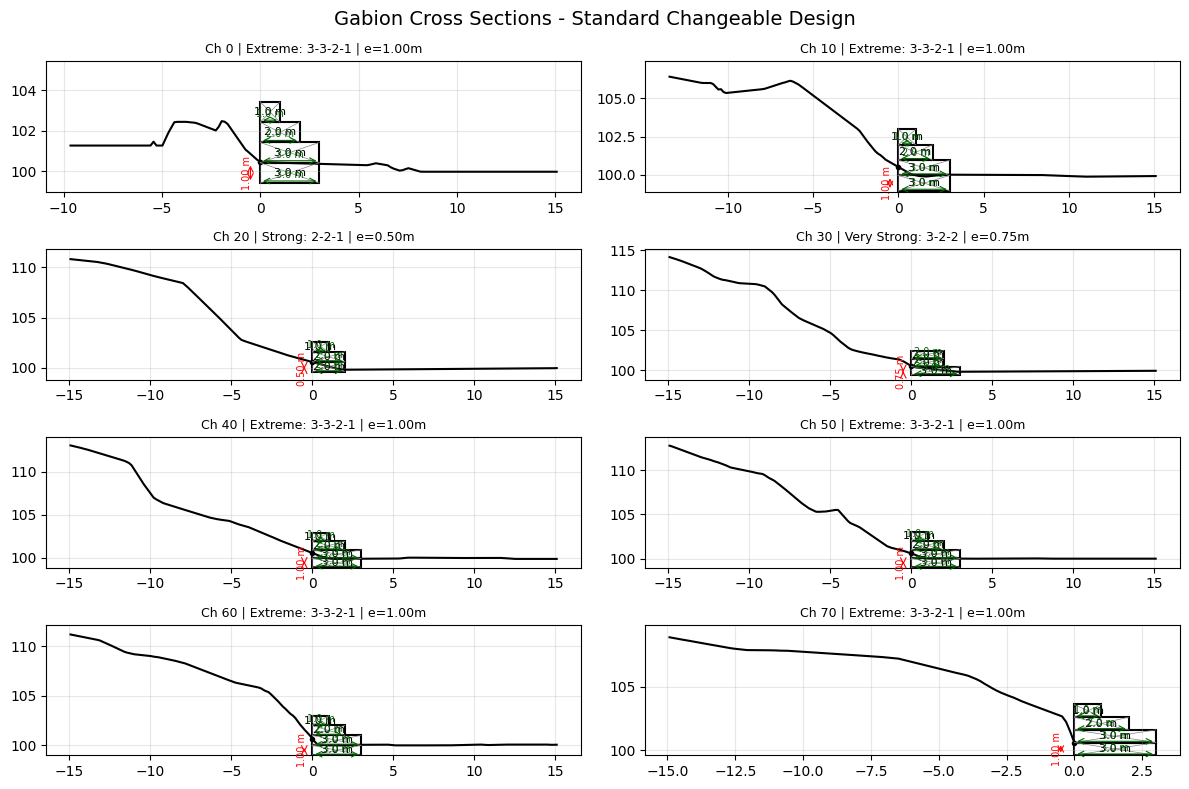

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------
# Chainages for gabion cross sections
# -------------------------------------------------
chainages = [0, 10, 20, 30, 40, 50, 60, 70]

# -------------------------------------------------
# Optional field-condition upgrades
# Add chainages where toe is wet / erosion is visible
# -------------------------------------------------
wet_zone_chainages = []          # edit if needed
erosion_risk_chainages = [] # edit if needed

# -------------------------------------------------
# Build automatic / standard design map
# -------------------------------------------------
design_by_chainage = build_standard_design_map(
    Xi, Yi, Zi,
    rear_edge_line=result["wall_geom"]["rear_edge_line"],
    chainages=chainages,
    half_length=15.0,
    n_points=200,
    wet_zone_chainages=wet_zone_chainages,
    erosion_risk_chainages=erosion_risk_chainages
)

# -------------------------------------------------
# Plot cross sections
# -------------------------------------------------
summary = plot_sections_subplots(
    Xi, Yi, Zi,
    rear_edge_line=result["wall_geom"]["rear_edge_line"],
    chainages=chainages,
    design_by_chainage=design_by_chainage,
    default_design="medium_2_layer",
    cols=2,
    figsize=(12, 8),
    show_dims=True,
    show_labels=True,
)


summary

### Automatic Design

Uses DEM (Xi, Yi, Zi)
Generates:
best toe alignment
slope-based drainage
invert levels
chainage-based sections

Strengths:

✅ Data-driven
✅ Consistent
✅ Fast iteration
✅ Handles complex terrain

Limitations:

❌ Doesn’t “understand” construction reality
❌ May overfit small terrain noise
❌ Needs engineering judgment

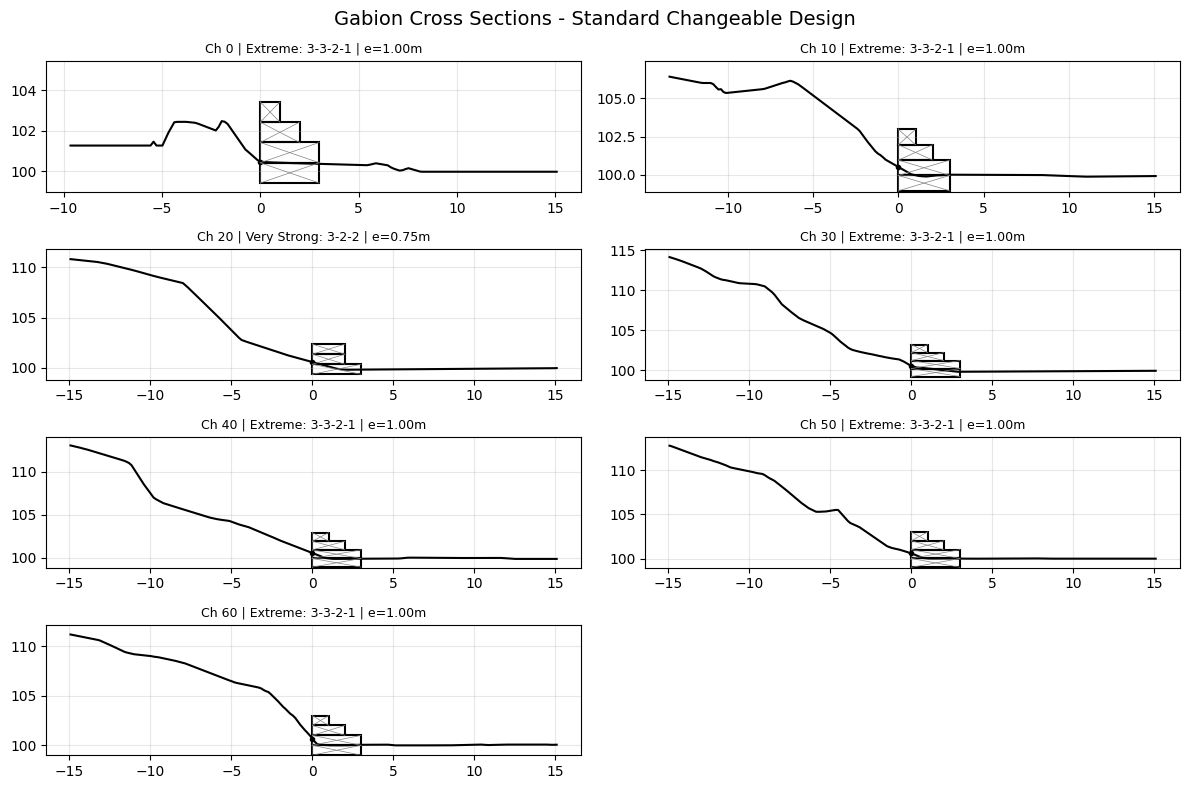

In [ ]:
# @title
chainages = list(range(0, 70, 10))

auto_design_map = build_standard_design_map(
    Xi, Yi, Zi,
    rear_edge_line=result["wall_geom"]["rear_edge_line"],
    chainages=chainages,
    wet_zone_chainages=[20, 30, 30],
    erosion_risk_chainages=[20,30]
)

summary = plot_sections_subplots(
    Xi, Yi, Zi,
    rear_edge_line=result["wall_geom"]["rear_edge_line"],
    chainages=chainages,
    design_by_chainage=auto_design_map,
    default_design="medium_2_layer",
    cols=2,
    figsize=(12, 8),
    #  save_path="Ranawana_Gabion_CS_auto.pdf"
)

### Manual Gabian Design

given:

clay soil
slight seepage
toe wet risk
complex slope

👉 Final choice:

AUTO for geometry
+
MANUAL for engineering decisions
=
BEST DESIGN
⚠️ What NOT to do
❌ Pure standard → too risky
❌ Pure auto → not practical
❌ Ignore drainage → main failure cause

In [ ]:
GABION_DESIGNS

{'light_1_layer': {'label': 'Light: 2',
  'widths': (2.0,),
  'default_embed': 0.3},
 'medium_2_layer': {'label': 'Medium: 2-1',
  'widths': (2.0, 1.0),
  'default_embed': 0.5},
 'strong_3_layer': {'label': 'Strong: 2-2-1',
  'widths': (2.0, 2.0, 1.0),
  'default_embed': 0.5},
 'very_strong_3_layer': {'label': 'Very Strong: 3-2-2',
  'widths': (3.0, 2.0, 2.0),
  'default_embed': 0.75},
 'extreme_4_layer': {'label': 'Extreme: 3-3-2-1',
  'widths': (3.0, 3.0, 2.0, 1.0),
  'default_embed': 1.0}}

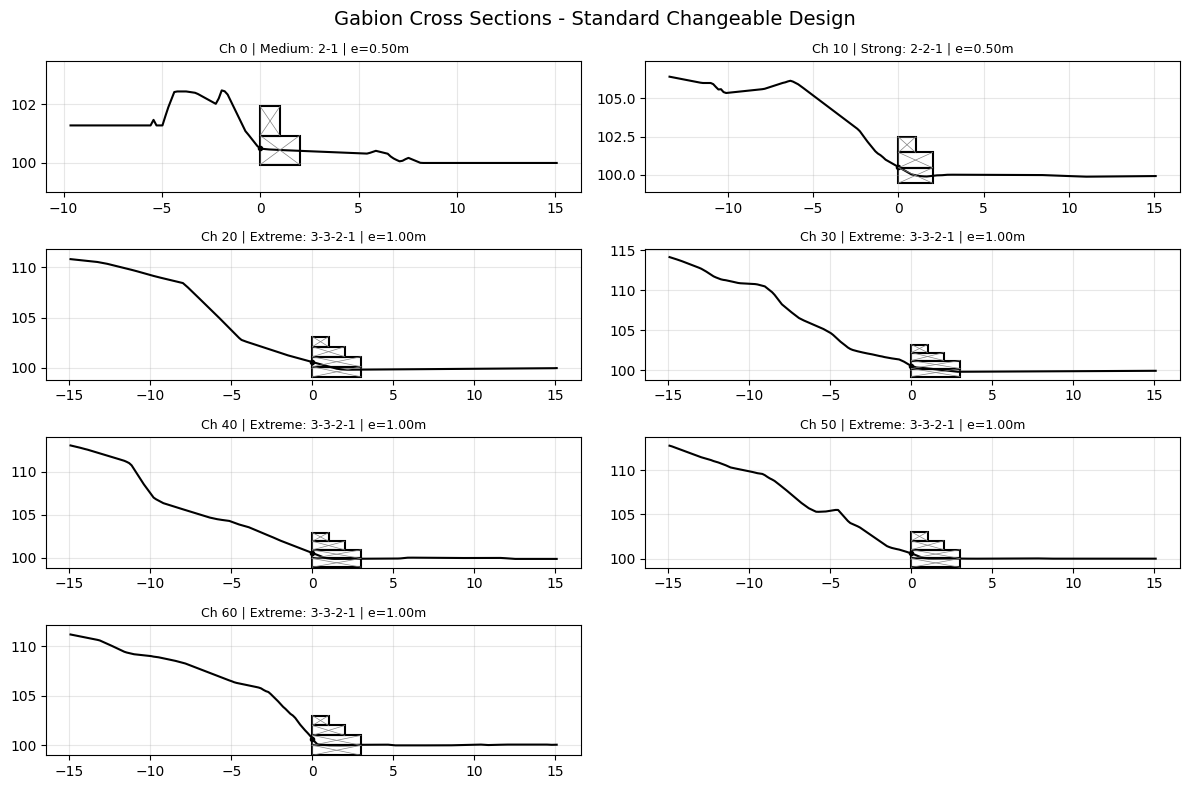

<Figure size 640x480 with 0 Axes>

Saved:
Ranawana_gabion_CS.csv
Ranawana_gabion_CS.pdf


In [ ]:
# @title
chainages = list(range(0, 70, 10))

design_by_chainage = {
    0:  "medium_2_layer",
    10: "strong_3_layer",
    20: "extreme_4_layer",
    30: "extreme_4_layer",
    40: "extreme_4_layer",
    50: "extreme_4_layer",
    60: "extreme_4_layer",
    70: "extreme_4_layer"
}

summary = plot_sections_subplots(
    Xi, Yi, Zi,
    rear_edge_line=result["wall_geom"]["rear_edge_line"],
    chainages=chainages,
    design_by_chainage=design_by_chainage,
    default_design="medium_2_layer",
    cols=2,
    figsize=(12, 8)
)
plt.savefig("Ranawana_gabion_CS_manual.pdf", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# Save all cross-section summaries to CSV
df_cs = pd.DataFrame(summary)
df_cs.to_csv("Ranawana_gabion_CS.csv", index=False)

plt.savefig(
    "Ranawana_gabion_CS.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:")
print("Ranawana_gabion_CS.csv")
print("Ranawana_gabion_CS.pdf")

### Single Gabian Section Plot

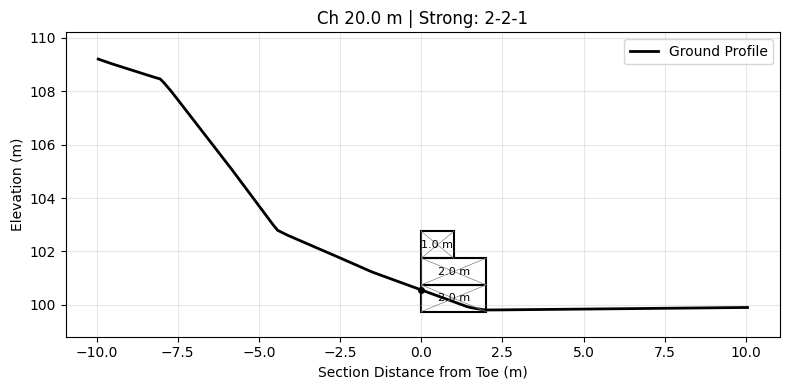

In [ ]:
# @title
plot_single_section(
    Xi, Yi, Zi,
    rear_edge_line=result["wall_geom"]["rear_edge_line"],
    chainage=20,
    design="strong_3_layer",
    half_length=10.0,
    n_points=200,
    figsize=(8, 4),
    show_dims=False,
    show_labels=True,
    save_path=None
)
plt.show()

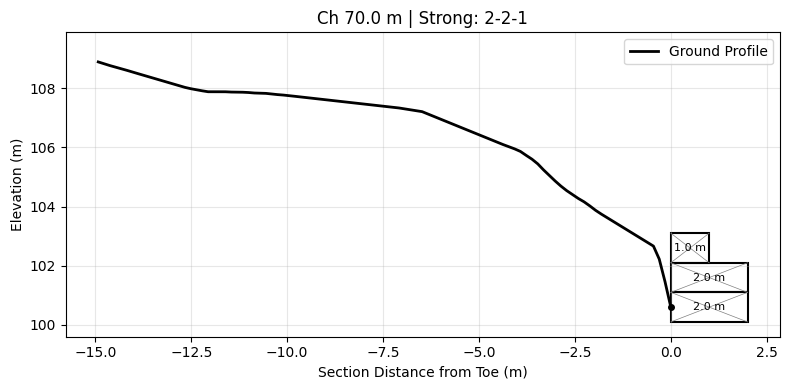

In [ ]:
# @title
plot_single_section(
    Xi, Yi, Zi,
    rear_edge_line=result["wall_geom"]["rear_edge_line"],
    chainage=70,
    design="strong_3_layer",
    half_length=15.0,
    n_points=200,
    figsize=(8, 4),
    show_dims=False,
    show_labels=True,
    save_path=None
)
plt.show()

### BOQ for for Gabion Toe Wall

In [ ]:
# @title

import math
import pandas as pd
import numpy as np
from dataclasses import dataclass, asdict

# =========================================================
# 1. CONFIG
# =========================================================
@dataclass
class BOQConfig:
    basket_len: float = 2.0
    basket_h: float = 1.0
    filter_width: float = 0.30
    drain_pipe_factor: float = 1.05
    stone_wastage: float = 1.08
    filter_wastage: float = 1.10
    geotextile_overlap: float = 1.10

    rate_basket: float = 0.0
    rate_stone_m3: float = 0.0
    rate_filter_m3: float = 0.0
    rate_geotextile_m2: float = 0.0
    rate_drain_m: float = 0.0
    rate_excavation_m3: float = 0.0
    rate_assembly_m: float = 0.0


# =========================================================
# 2. SEGMENT BUILDER
# =========================================================
def build_boq_segments(rear_edge_line, design_map):
    """
    Convert chainage-based design map into BOQ segments.
    Each chainage applies until the next chainage or end of wall.
    """
    L = float(rear_edge_line.length)
    chainages = sorted(float(ch) for ch in design_map.keys())

    segments = []
    for i, ch_start in enumerate(chainages):
        ch_end = chainages[i + 1] if i < len(chainages) - 1 else L

        if ch_end <= ch_start:
            continue

        item = design_map[ch_start]

        segments.append({
            "ch_start": float(ch_start),
            "ch_end": float(ch_end),
            "length": float(ch_end - ch_start),
            "design_name": item["design_name"],
            "label": item["label"],
            "widths": tuple(item["widths"]),
            "embed": float(item["embed"]),
            "drain": bool(item.get("drain", False)),
            "slope_deg": float(item.get("slope_deg", np.nan)),
            "relief_m": float(item.get("relief_m", np.nan))
                if item.get("relief_m", None) is not None else np.nan,
        })

    return segments


# =========================================================
# 3. ONE SEGMENT QUANTITIES
# =========================================================
def calculate_one_segment_boq(seg, cfg: BOQConfig):
    seg_len = float(seg["length"])
    widths = tuple(seg["widths"])
    layers = len(widths)
    embed = float(seg["embed"])

    n_units = math.ceil(seg_len / cfg.basket_len)

    baskets = n_units * layers

    gabion_volume = n_units * sum(w * cfg.basket_h * cfg.basket_len for w in widths)
    stone_volume = gabion_volume * cfg.stone_wastage

    filter_height = layers * cfg.basket_h
    filter_volume = seg_len * cfg.filter_width * filter_height * cfg.filter_wastage

    geotextile_area = seg_len * filter_height * cfg.geotextile_overlap

    drain_len = seg_len * cfg.drain_pipe_factor if seg["drain"] else 0.0

    excavation_width = max(widths)
    excavation_volume = seg_len * excavation_width * embed

    amount = (
        baskets * cfg.rate_basket +
        stone_volume * cfg.rate_stone_m3 +
        filter_volume * cfg.rate_filter_m3 +
        geotextile_area * cfg.rate_geotextile_m2 +
        drain_len * cfg.rate_drain_m +
        excavation_volume * cfg.rate_excavation_m3 +
        seg_len * cfg.rate_assembly_m
    )

    return {
        "Ch_Start": round(seg["ch_start"], 2),
        "Ch_End": round(seg["ch_end"], 2),
        "Seg_Length_m": round(seg_len, 2),
        "Design_Name": seg["design_name"],
        "Design": seg["label"],
        "Widths": "-".join(
            str(int(w)) if float(w).is_integer() else str(w) for w in widths
        ),
        "Layers": layers,
        "Embed_m": round(embed, 2),
        "Drain": bool(seg["drain"]),
        "Slope_deg": round(seg["slope_deg"], 2) if not np.isnan(seg["slope_deg"]) else np.nan,
        "Relief_m": round(seg["relief_m"], 2) if not np.isnan(seg["relief_m"]) else np.nan,
        "Units_Along": int(n_units),
        "Baskets_No": int(baskets),
        "Gabion_Vol_m3": round(gabion_volume, 2),
        "Stone_Vol_m3": round(stone_volume, 2),
        "Filter_Vol_m3": round(filter_volume, 2),
        "Geotextile_m2": round(geotextile_area, 2),
        "Drain_m": round(drain_len, 2),
        "Excavation_m3": round(excavation_volume, 2),
        "Amount": round(amount, 2),
    }


# =========================================================
# 4. FULL SEGMENT TABLE
# =========================================================
def calculate_boq_by_segment(segments, cfg: BOQConfig):
    rows = [calculate_one_segment_boq(seg, cfg) for seg in segments]
    return pd.DataFrame(rows)


# =========================================================
# 5. SUMMARIES
# =========================================================
def summarize_boq(df_seg):
    df_total = pd.DataFrame([{
        "Total_Length_m": df_seg["Seg_Length_m"].sum(),
        "Total_Baskets_No": df_seg["Baskets_No"].sum(),
        "Total_Gabion_Vol_m3": df_seg["Gabion_Vol_m3"].sum(),
        "Total_Stone_Vol_m3": df_seg["Stone_Vol_m3"].sum(),
        "Total_Filter_Vol_m3": df_seg["Filter_Vol_m3"].sum(),
        "Total_Geotextile_m2": df_seg["Geotextile_m2"].sum(),
        "Total_Drain_m": df_seg["Drain_m"].sum(),
        "Total_Excavation_m3": df_seg["Excavation_m3"].sum(),
        "Grand_Total": df_seg["Amount"].sum(),
    }])

    df_by_design = (
        df_seg.groupby(["Design_Name", "Design"], dropna=False)[[
            "Seg_Length_m",
            "Baskets_No",
            "Gabion_Vol_m3",
            "Stone_Vol_m3",
            "Filter_Vol_m3",
            "Geotextile_m2",
            "Drain_m",
            "Excavation_m3",
            "Amount"
        ]]
        .sum()
        .reset_index()
    )

    return df_total, df_by_design


# =========================================================
# 6. EXPORT
# =========================================================
def export_boq_tables(df_seg, df_by_design, df_total, prefix="Gabion_BOQ"):
    seg_file = f"{prefix}_by_Segment.csv"
    design_file = f"{prefix}_by_Design.csv"
    total_file = f"{prefix}_Total.csv"

    df_seg.to_csv(seg_file, index=False)
    df_by_design.to_csv(design_file, index=False)
    df_total.to_csv(total_file, index=False)

    print("Saved:")
    print(f" - {seg_file}")
    print(f" - {design_file}")
    print(f" - {total_file}")


# =========================================================
# 7. MASTER RUNNER
# =========================================================
def run_gabion_boq(rear_edge_line, design_map, cfg=None, export_csv=True, prefix="Gabion_BOQ"):
    if cfg is None:
        cfg = BOQConfig()

    segments = build_boq_segments(rear_edge_line, design_map)
    df_seg = calculate_boq_by_segment(segments, cfg)
    df_total, df_by_design = summarize_boq(df_seg)

    print("SEGMENT BOQ")
    display(df_seg)
    print()
    print("SUMMARY BY DESIGN")
    display(df_by_design)

    print()
    print("TOTAL SUMMARY")
    display(df_total)

    if export_csv:
        export_boq_tables(df_seg, df_by_design, df_total, prefix=prefix)

    return {
        "config": asdict(cfg),
        "segments": segments,
        "df_seg": df_seg,
        "df_by_design": df_by_design,
        "df_total": df_total,
    }

In [ ]:
# @title
cfg = BOQConfig(
    basket_len=2.0,
    basket_h=1.0,
    filter_width=0.30,
    drain_pipe_factor=1.05,
    stone_wastage=1.08,
    filter_wastage=1.10,
    geotextile_overlap=1.10,

    rate_basket=0.0,
    rate_stone_m3=0.0,
    rate_filter_m3=0.0,
    rate_geotextile_m2=0.0,
    rate_drain_m=0.0,
    rate_excavation_m3=0.0,
    rate_assembly_m=0.0
)

boq_out = run_gabion_boq(
    rear_edge_line=result["wall_geom"]["rear_edge_line"],
    design_map=auto_design_map,
    cfg=cfg,
    export_csv=True,
    prefix="Gabion_BOQ"
)

SEGMENT BOQ


,Ch_Start,Ch_End,Seg_Length_m,Design_Name,Design,Widths,Layers,Embed_m,Drain,Slope_deg,Relief_m,Units_Along,Baskets_No,Gabion_Vol_m3,Stone_Vol_m3,Filter_Vol_m3,Geotextile_m2,Drain_m,Excavation_m3,Amount
0,0.0,10.00,10.00,extreme_4_layer,Extreme: 3-3-2-1,3-3-2-1,4,1.00,True,NaN,2.00,5,20,90.0,97.2,13.20,44.00,10.50,30.00,0.0
1,10.0,20.00,10.00,extreme_4_layer,Extreme: 3-3-2-1,3-3-2-1,4,1.00,True,NaN,3.00,5,20,90.0,97.2,13.20,44.00,10.50,30.00,0.0
2,20.0,30.00,10.00,very_strong_3_layer,Very Strong: 3-2-2,3-2-2,3,0.75,True,NaN,1.47,5,15,70.0,75.6,9.90,33.00,10.50,22.50,0.0
3,30.0,40.00,10.00,extreme_4_layer,Extreme: 3-3-2-1,3-3-2-1,4,1.00,True,NaN,1.67,5,20,90.0,97.2,13.20,44.00,10.50,30.00,0.0
4,40.0,50.00,10.00,extreme_4_layer,Extreme: 3-3-2-1,3-3-2-1,4,1.00,True,NaN,2.28,5,20,90.0,97.2,13.20,44.00,10.50,30.00,0.0
5,50.0,60.00,10.00,extreme_4_layer,Extreme: 3-3-2-1,3-3-2-1,4,1.00,True,NaN,2.73,5,20,90.0,97.2,13.20,44.00,10.50,30.00,0.0
6,60.0,68.44,8.44,extreme_4_layer,Extreme: 3-3-2-1,3-3-2-1,4,1.00,True,NaN,4.91,5,20,90.0,97.2,11.14,37.12,8.86,25.31,0.0



SUMMARY BY DESIGN


,Design_Name,Design,Seg_Length_m,Baskets_No,Gabion_Vol_m3,Stone_Vol_m3,Filter_Vol_m3,Geotextile_m2,Drain_m,Excavation_m3,Amount
0,extreme_4_layer,Extreme: 3-3-2-1,58.44,120,540.0,583.2,77.14,257.12,61.36,175.31,0.0
1,very_strong_3_layer,Very Strong: 3-2-2,10.00,15,70.0,75.6,9.90,33.00,10.50,22.50,0.0



TOTAL SUMMARY


,Total_Length_m,Total_Baskets_No,Total_Gabion_Vol_m3,Total_Stone_Vol_m3,Total_Filter_Vol_m3,Total_Geotextile_m2,Total_Drain_m,Total_Excavation_m3,Grand_Total
0,68.44,135,610.0,658.8,87.04,290.12,71.86,197.81,0.0


Saved:
 - Gabion_BOQ_by_Segment.csv
 - Gabion_BOQ_by_Design.csv
 - Gabion_BOQ_Total.csv


### Toe (rear edge z alignment):

In [ ]:
# @title
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

def extract_toe_xyz(result, Xi, Yi, Zi, embed=0.0):
    """
    Extract toe alignment XYZ from DEM.

    embed:
        0.0 -> ground level
        >0  -> buried gabion base level
    """

    line = result["wall_geom"]["rear_edge_line"]

    coords = np.array(line.coords)
    x = coords[:, 0]
    y = coords[:, 1]

    x_flat = Xi.ravel()
    y_flat = Yi.ravel()
    z_flat = Zi.ravel()

    valid = ~np.isnan(z_flat)

    z_ground = griddata(
        (x_flat[valid], y_flat[valid]),
        z_flat[valid],
        (x, y),
        method="linear"
    )

    z_toe = z_ground - embed

    chainage = np.zeros(len(x))
    for i in range(1, len(x)):
        chainage[i] = chainage[i-1] + np.sqrt(
            (x[i] - x[i-1])**2 + (y[i] - y[i-1])**2
        )

    df = pd.DataFrame({
        "chainage_m": chainage,
        "x": x,
        "y": y,
        "z_ground_m": z_ground,
        "z_toe_m": z_toe,
        "embed_m": embed
    })

    return df

    df_toe = extract_toe_xyz(
    result,
    Xi, Yi, Zi,
    embed=0.0   # use 0.3 or 0.5 if gabion base is buried
    )

df_toe = extract_toe_xyz(
    result,
    Xi, Yi, Zi,
    embed=0.0   # change later if needed
)

df_toe.to_csv("Ranawana_toe_alignment.csv", index=False)

print("Saved: Ranawana_toe_alignment.csv")
print(df_toe.head())

Saved: Ranawana_toe_alignment.csv
   chainage_m           x            y  z_ground_m     z_toe_m  embed_m
0    0.000000  990.050422  1010.025690  100.474360  100.474360      0.0
1    0.499101  990.328170  1009.611012  100.492353  100.492353      0.0
2    0.998974  990.641445  1009.221484  100.665978  100.665978      0.0
3    1.498834  990.953535  1008.831023  100.732698  100.732698      0.0
4    1.998489  991.236961  1008.419531  100.589871  100.589871      0.0


In [ ]:
# @title
import ezdxf

def save_toe_dxf(x, y, z, filename="toe_alignment.dxf"):
    doc = ezdxf.new()
    msp = doc.modelspace()

    # 3D polyline
    points = [(float(x[i]), float(y[i]), float(z[i])) for i in range(len(x))]

    msp.add_polyline3d(points)

    doc.saveas(filename)
    print(f"Saved: {filename}")

# save ground line
save_toe_dxf(x, y, z, "Ranawana_toe_ground.dxf")

Saved: Ranawana_toe_ground.dxf


In [ ]:
# @title
import numpy as np
import math

# =========================================================
# INPUT
# =========================================================
rear_edge_line = result["wall_geom"]["rear_edge_line"]

# gabion configuration (your design)
basket_length = 2.0   # along wall
layers = [2.0, 2.0, 1.0]   # 2–2–1 (widths)
n_layers = len(layers)

# =========================================================
# 1. WALL LENGTH
# =========================================================
L = rear_edge_line.length
print(f"\n📏 Gabion Wall Length = {L:.2f} m")

# =========================================================
# 2. NUMBER OF GABION UNITS (ALONG LENGTH)
# =========================================================
n_units_length = math.ceil(L / basket_length)

print(f"🧱 Units along length (2m baskets) = {n_units_length}")

# =========================================================
# 3. TOTAL GABION BASKETS
# =========================================================
total_baskets = n_units_length * n_layers

print(f"🧱 Number of layers (2-2-1) = {n_layers}")
print(f"🧱 Total gabion baskets = {total_baskets}")

# =========================================================
# 4. VOLUME ESTIMATE
# =========================================================
# each basket = 2m x 1m x 1m = 2 m³
volume_per_basket = 2.0
total_volume = total_baskets * volume_per_basket

print(f"📦 Total gabion volume ≈ {total_volume:.2f} m³")

# =========================================================
# 5. CHAINAGES (10 m interval, auto-fit)
# =========================================================
chainages = list(range(0, int(L), 10))

# ensure last point included
if not chainages or chainages[-1] != round(L):
    chainages.append(round(L, 1))

print(f"\n📍 Chainages (10 m interval):")
print(chainages)

# =========================================================
# 6. SUMMARY
# =========================================================
print("\n✅ SUMMARY")
print("-----------------------------")
print(f"Wall Length        : {L:.2f} m")
print(f"Gabion Units       : {n_units_length}")
print(f"Layers             : {n_layers} (2-2-1)")
print(f"Total Baskets      : {total_baskets}")
print(f"Total Volume       : {total_volume:.2f} m³")
print(f"Sections (10m)     : {len(chainages)}")


📏 Gabion Wall Length = 68.44 m
🧱 Units along length (2m baskets) = 35
🧱 Number of layers (2-2-1) = 3
🧱 Total gabion baskets = 105
📦 Total gabion volume ≈ 210.00 m³

📍 Chainages (10 m interval):
[0, 10, 20, 30, 40, 50, 60, 68.4]

✅ SUMMARY
-----------------------------
Wall Length        : 68.44 m
Gabion Units       : 35
Layers             : 3 (2-2-1)
Total Baskets      : 105
Total Volume       : 210.00 m³
Sections (10m)     : 8


Front elevation using automatic design

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def front_view_gabion_wall_auto(
    Xi, Yi, Zi,
    rear_edge_line,
    auto_design_map,
    basket_len=2.0,
    basket_h=1.0,
    figsize=(14, 5),
    title="Front Elevation of Gabion Wall (Automatic Design)",
    save_path=None
):
    """
    Front elevation of gabion wall using auto_design_map.

    auto_design_map format:
    {
        0:  {"widths": (2.0, 1.0), "embed": 0.5, "label": "..."},
        10: {"widths": (2.0, 2.0, 1.0), "embed": 0.5, "label": "..."},
        20: {"widths": (3.0, 2.0, 2.0), "embed": 0.75, "label": "..."},
        ...
    }
    """

    # -----------------------------------------------------
    # 1. alignment coordinates
    # -----------------------------------------------------
    coords = np.array(rear_edge_line.coords)
    x = coords[:, 0]
    y = coords[:, 1]

    # chainage along alignment
    ch = np.zeros(len(x))
    for i in range(1, len(x)):
        ch[i] = ch[i - 1] + np.hypot(x[i] - x[i - 1], y[i] - y[i - 1])

    # -----------------------------------------------------
    # 2. sample ground z along wall
    # -----------------------------------------------------
    x_flat = Xi.ravel()
    y_flat = Yi.ravel()
    z_flat = Zi.ravel()
    valid = ~np.isnan(z_flat)

    z_ground = griddata(
        (x_flat[valid], y_flat[valid]),
        z_flat[valid],
        (x, y),
        method="linear"
    )

    # -----------------------------------------------------
    # 3. resample along wall at basket spacing
    # -----------------------------------------------------
    ch_new = np.arange(0, ch[-1] + basket_len, basket_len)
    x_new = np.interp(ch_new, ch, x)
    y_new = np.interp(ch_new, ch, y)
    z_ground_new = np.interp(ch_new, ch, z_ground)

    # -----------------------------------------------------
    # 4. prepare design intervals
    # -----------------------------------------------------
    design_chainages = sorted(auto_design_map.keys())

    def get_design_at_chainage(chainage):
        """
        Use the latest design starting at or before this chainage.
        """
        chosen_key = design_chainages[0]
        for k in design_chainages:
            if chainage >= k:
                chosen_key = k
            else:
                break
        return auto_design_map[chosen_key]

    # -----------------------------------------------------
    # 5. plot front elevation
    # -----------------------------------------------------
    fig, ax = plt.subplots(figsize=figsize)

    # ground line
    ax.plot(ch_new, z_ground_new, color="black", linewidth=2, label="Ground Level")

    # design bands for labels/colors
    design_styles = {
        "light_1_layer": "white",
        "medium_2_layer": "0.92",
        "strong_3_layer": "0.88",
        "very_strong_3_layer": "0.84",
        "extreme_4_layer": "0.80",
    }

    # -----------------------------------------------------
    # 6. draw baskets segment by segment
    # -----------------------------------------------------
    for i in range(len(ch_new) - 1):
        ch0 = ch_new[i]
        ch1 = ch_new[i + 1]
        seg_len = ch1 - ch0

        design = get_design_at_chainage(ch0)
        widths = tuple(design["widths"])
        embed = float(design["embed"])
        design_name = design.get("design_name", "custom")

        base_z = z_ground_new[i] - embed
        facecolor = design_styles.get(design_name, "0.9")

        for j, w in enumerate(widths):
            z0 = base_z + j * basket_h

            rect = plt.Rectangle(
                (ch0, z0),
                seg_len,
                basket_h,
                fill=True,
                facecolor=facecolor,
                edgecolor="black",
                linewidth=1.0
            )
            ax.add_patch(rect)

            # hatch-like diagonals
            ax.plot([ch0, ch0 + seg_len], [z0, z0 + basket_h], color="gray", linewidth=0.35)
            ax.plot([ch0, ch0 + seg_len], [z0 + basket_h, z0], color="gray", linewidth=0.35)

    # -----------------------------------------------------
    # 7. mark design changes
    # -----------------------------------------------------
    for k in design_chainages:
        if k <= ch_new[-1]:
            d = auto_design_map[k]
            label = d.get("label", d.get("design_name", "design"))
            ax.axvline(k, color="black", linestyle="--", linewidth=0.6, alpha=0.6)
            ax.text(
                k,
                np.nanmax(z_ground_new) + 0.4,
                label,
                rotation=90,
                fontsize=7,
                va="bottom",
                ha="center"
            )

    # -----------------------------------------------------
    # 8. labels
    # -----------------------------------------------------
    ax.set_xlabel("Chainage along wall (m)")
    ax.set_ylabel("Elevation (m)")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.invert_xaxis()
    max_layers = max(len(v["widths"]) for v in auto_design_map.values())
    max_embed = max(float(v["embed"]) for v in auto_design_map.values())

    ymin = np.nanmin(z_ground_new - max_embed) - 0.5
    ymax = np.nanmax(z_ground_new) + max_layers * basket_h + 0.8
    ax.set_ylim(ymin, ymax)

    # chainage ticks every 10 m
    xticks = np.arange(0, ch_new[-1] + 1, 10)
    ax.set_xticks(xticks)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        print(f"Saved: {save_path}")

    plt.show()

    return {
        "chainage": ch_new,
        "x": x_new,
        "y": y_new,
        "z_ground": z_ground_new
    }

Saved: gabion_front_elevation_auto.pdf


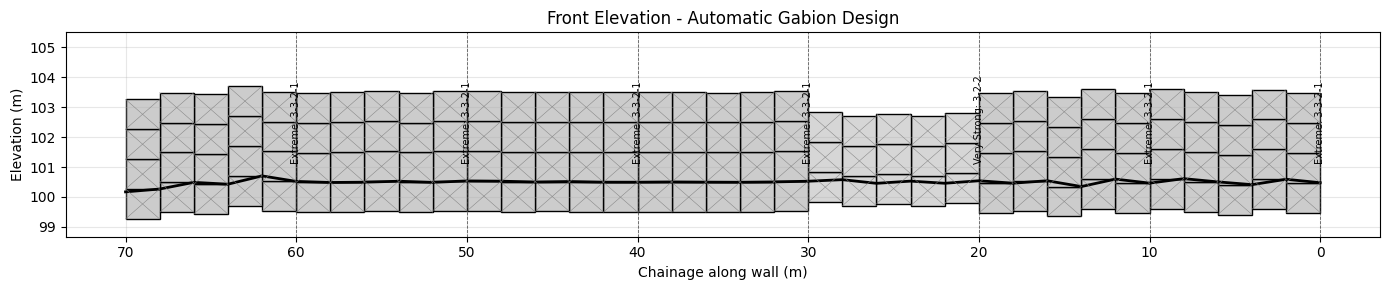

In [ ]:
# @title
front = front_view_gabion_wall_auto(
    Xi, Yi, Zi,
    rear_edge_line=result["wall_geom"]["rear_edge_line"],
    auto_design_map=auto_design_map,
    basket_len=2.0,
    basket_h=1.0,
    figsize=(14, 3),
    title="Front Elevation - Automatic Gabion Design",
    save_path="gabion_front_elevation_auto.pdf"
)

### Toe Protection Wall
extract a toe / wall rear-edge design line from your DEM
smooth it
use it as the slope-side gabion wall edge
offset outward for the stronger gabion section
create simple wall polygons for plotting

This assumes you already have:

Xi, Yi, Zi → DEM grid
optional unstable zone polygon later if you want to clip more precisely

### Gabian Wall for Toe

In [ ]:
# @title
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.interpolate import splprep, splev
from matplotlib.path import Path
from shapely.geometry import LineString, Polygon, MultiLineString
from shapely.ops import unary_union
vxvxv
# =========================================================
# 1. EXTRACT CONTOUR SEGMENTS AT TARGET ELEVATION
# =========================================================
# =========================================================
# 1. EXTRACT CONTOUR SEGMENTS AT TARGET ELEVATION
# =========================================================
def extract_contour_lines(Xi, Yi, Zi, level=100.5):
    fig, ax = plt.subplots()
    cs = ax.contour(Xi, Yi, Zi, levels=[level])
    plt.close(fig)

    lines = []

    if len(cs.allsegs) == 0:
        return lines

    for seg in cs.allsegs[0]:
        if seg is not None and len(seg) >= 2:
            try:
                lines.append(LineString(seg))
            except Exception:
                continue

    return lines


# =========================================================
# 2. CHOOSE LONGEST / BEST TOE-LIKE SEGMENT
# =========================================================
def choose_best_contour_line(lines, min_length=5.0):
    """
    Choose the longest valid contour segment
    """
    valid = [ln for ln in lines if ln.length >= min_length]
    if not valid:
        return None
    return max(valid, key=lambda g: g.length)


# =========================================================
# 3. SMOOTH A LINE USING SPLINE
# =========================================================
def smooth_line(line, smoothing=2.0, n_points=300):
    """
    Smooth a LineString with spline interpolation
    """
    coords = np.array(line.coords)

    if len(coords) < 4:
        return line

    x = coords[:, 0]
    y = coords[:, 1]

    # remove duplicate consecutive points
    keep = [0]
    for i in range(1, len(coords)):
        if np.hypot(x[i] - x[keep[-1]], y[i] - y[keep[-1]]) > 1e-6:
            keep.append(i)

    x = x[keep]
    y = y[keep]

    if len(x) < 4:
        return LineString(np.column_stack([x, y]))

    try:
        tck, u = splprep([x, y], s=smoothing)
        u_new = np.linspace(0, 1, n_points)
        x_new, y_new = splev(u_new, tck)
        return LineString(np.column_stack([x_new, y_new]))
    except Exception:
        return LineString(np.column_stack([x, y]))


# =========================================================
# 4. ORIENT LINE CONSISTENTLY
# =========================================================
def orient_line_left_to_right(line):
    coords = np.array(line.coords)
    if coords[0, 0] > coords[-1, 0]:
        coords = coords[::-1]
    return LineString(coords)


# =========================================================
# 5. OFFSET LINE OUTWARD
# =========================================================
def offset_line(line, distance, side='right'):
    """
    side='right' usually means downslope/outward if line direction is consistent.
    You may switch to 'left' if geometry offsets the wrong way.
    """
    try:
        off = line.parallel_offset(distance, side=side, join_style=2)
        if off.is_empty:
            return None

        if isinstance(off, MultiLineString):
            # choose longest part
            off = max(off.geoms, key=lambda g: g.length)

        return LineString(off.coords)
    except Exception:
        return None


# =========================================================
# 6. BUILD WALL BAND / POLYGON BETWEEN 2 LINES
# =========================================================
def lines_to_polygon(line1, line2):
    """
    Make polygon between two lines
    """
    c1 = np.array(line1.coords)
    c2 = np.array(line2.coords)

    poly_coords = np.vstack([c1, c2[::-1], c1[:1]])
    return Polygon(poly_coords)


# =========================================================
# 7. SAMPLE LINE INTO 2 m GABION POSITIONS
# =========================================================
def sample_line_by_spacing(line, spacing=2.0):
    """
    Return points every 'spacing' meters along line
    """
    n = max(2, int(line.length / spacing) + 1)
    distances = np.linspace(0, line.length, n)
    pts = [line.interpolate(d) for d in distances]
    return np.array([[p.x, p.y] for p in pts])


# =========================================================
# 8. COMPUTE SIMPLE SLOPE GRID
# =========================================================
def compute_slope_grid(Xi, Yi, Zi):
    dy = np.mean(np.diff(Yi[:, 0]))
    dx = np.mean(np.diff(Xi[0, :]))
    dz_dy, dz_dx = np.gradient(Zi, dy, dx)
    slope_deg = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
    return slope_deg


# =========================================================
# 9. OPTIONAL: SELECT CONTOUR NEAR STEEPER TOE ZONE
# =========================================================
def score_line_by_slope(line, Xi, Yi, slope_grid, sample_n=80):
    """
    Higher score if line passes near steeper area upslope
    """
    dists = np.linspace(0, line.length, sample_n)
    vals = []

    for d in dists:
        p = line.interpolate(d)
        x, y = p.x, p.y

        ix = np.argmin(np.abs(Xi[0, :] - x))
        iy = np.argmin(np.abs(Yi[:, 0] - y))
        vals.append(slope_grid[iy, ix])

    return np.nanmean(vals)


def choose_best_line_by_slope(lines, Xi, Yi, Zi, min_length=5.0):
    slope_grid = compute_slope_grid(Xi, Yi, Zi)
    valid = [ln for ln in lines if ln.length >= min_length]

    if not valid:
        return None

    scores = [(ln, score_line_by_slope(ln, Xi, Yi, slope_grid)) for ln in valid]
    best = max(scores, key=lambda t: t[1])[0]
    return best


# =========================================================
# 10. BUILD FULL GABION WALL GEOMETRY
# =========================================================
def build_gabion_wall_geometry(rear_edge_line, offset_side='right'):
    """
    Stronger Option 2:
      Bottom = 2 m
      Middle = 2 m
      Top    = 1 m
    rear_edge_line is slope-side back edge of wall
    """

    rear_edge_line = orient_line_left_to_right(rear_edge_line)

    # Outward/front edges
    front_edge_bottom = offset_line(rear_edge_line, 2.0, side=offset_side)
    front_edge_middle = offset_line(rear_edge_line, 2.0, side=offset_side)
    front_edge_top    = offset_line(rear_edge_line, 1.0, side=offset_side)

    # Drain line slightly behind or along rear base zone
    drain_pipe_line = offset_line(rear_edge_line, 0.30, side=offset_side)

    if front_edge_bottom is None or front_edge_top is None:
        raise ValueError("Offset failed. Try side='left' instead of side='right'.")

    # Wall footprint polygons
    bottom_poly = lines_to_polygon(rear_edge_line, front_edge_bottom)
    middle_poly = lines_to_polygon(rear_edge_line, front_edge_middle)
    top_poly    = lines_to_polygon(rear_edge_line, front_edge_top)

    return {
        "rear_edge_line": rear_edge_line,
        "front_edge_bottom": front_edge_bottom,
        "front_edge_middle": front_edge_middle,
        "front_edge_top": front_edge_top,
        "drain_pipe_line": drain_pipe_line,
        "bottom_poly": bottom_poly,
        "middle_poly": middle_poly,
        "top_poly": top_poly
    }


# =========================================================
# 11. PLOT EVERYTHING
# =========================================================
def plot_gabion_wall_layout(Xi, Yi, Zi, wall_geom, levels=30, title="Gabion Toe Wall Layout"):


    # DEM contours
    plt.contour(Xi, Yi, Zi, levels=levels, colors="brown", linewidths=0.5)


    # Rear edge
    rear = np.array(wall_geom["rear_edge_line"].coords)
    plt.plot(rear[:, 0], rear[:, 1], 'k-', linewidth=1, label="Rear Edge (Slope Side)")

    # Front edges
    fb = np.array(wall_geom["front_edge_bottom"].coords)
    ft = np.array(wall_geom["front_edge_top"].coords)

    plt.plot(fb[:, 0], fb[:, 1], 'r--', linewidth=1, label="Front Edge Bottom (2 m)")
    plt.plot(ft[:, 0], ft[:, 1], 'b--', linewidth=1, label="Front Edge Top (1 m)")

    # Drain line
    if wall_geom["drain_pipe_line"] is not None:
        dp = np.array(wall_geom["drain_pipe_line"].coords)
        plt.plot(dp[:, 0], dp[:, 1], color="cyan", linewidth=0.5, label="Drain Pipe Line")

    # Gabion basket points along rear line every 2m
    pts = sample_line_by_spacing(wall_geom["rear_edge_line"], spacing=2.0)
    plt.scatter(pts[:, 0], pts[:, 1], c="black", s=5, label="2 m Gabion Module Points")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()



# =========================================================
# 12. MAIN FUNCTION
# =========================================================
def design_gabion_toe_wall_from_dem(
    Xi, Yi, Zi,
    target_level=100.5,
    smoothing=2.0,
    min_length=5.0,
    offset_side='right',
    use_slope_scoring=True
):
    """
    Full workflow:
      1. extract contour
      2. select best line
      3. smooth it
      4. build gabion wall geometry
    """

    lines = extract_contour_lines(Xi, Yi, Zi, level=target_level)

    if len(lines) == 0:
        raise ValueError("No contour lines found at this elevation.")

    if use_slope_scoring:
        best_line = choose_best_line_by_slope(lines, Xi, Yi, Zi, min_length=min_length)
    else:
        best_line = choose_best_contour_line(lines, min_length=min_length)

    if best_line is None:
        raise ValueError("No suitable contour segment found.")

    smooth_best = smooth_line(best_line, smoothing=smoothing, n_points=300)
    wall_geom = build_gabion_wall_geometry(smooth_best, offset_side=offset_side)

    return {
        "raw_lines": lines,
        "best_line": best_line,
        "smooth_best_line": smooth_best,
        "wall_geom": wall_geom
    }

Full cleaned gabion wall alignment Options



In [ ]:
# @title
# =========================================================
# FINAL CLEAN GABION TOE WALL ALIGNMENT CODE
# Supports NumPy arrays + Shapely geometries
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import griddata

# =========================================================
# 1. GEOMETRY HELPERS
# =========================================================

def to_xy_array(line):
    """
    Convert geometry / line into Nx2 NumPy array.

    Supports:
    - NumPy array shape (N,2) or (N,>=2)
    - list of [x,y]
    - shapely LineString
    - shapely MultiLineString (merged into longest part)
    """
    if line is None:
        return None

    # shapely LineString
    if hasattr(line, "geom_type"):
        gtype = line.geom_type

        if gtype == "LineString":
            arr = np.array(line.coords, dtype=float)
            return arr[:, :2]

        elif gtype == "MultiLineString":
            parts = [np.array(part.coords, dtype=float)[:, :2] for part in line.geoms if len(part.coords) >= 2]
            if len(parts) == 0:
                return None
            lengths = [line_length_xy(p) for p in parts]
            return parts[int(np.argmax(lengths))]

    # generic shapely-like object with coords
    if hasattr(line, "coords"):
        arr = np.array(line.coords, dtype=float)
        if arr.ndim == 2 and arr.shape[1] >= 2:
            return arr[:, :2]

    # numpy / list
    arr = np.asarray(line, dtype=float)
    if arr.ndim == 2 and arr.shape[1] >= 2:
        return arr[:, :2]

    return None


def line_length_xy(line):
    """
    Polyline 2D length
    """
    line = to_xy_array(line)
    if line is None or len(line) < 2:
        return 0.0

    d = np.sqrt(np.sum(np.diff(line, axis=0)**2, axis=1))
    return float(np.sum(d))


def smooth_line(line, sigma=2.0):
    """
    Smooth x and y coordinates separately
    """
    line = to_xy_array(line)
    if line is None or len(line) < 5 or sigma <= 0:
        return line.copy() if line is not None else None

    x = gaussian_filter1d(line[:, 0], sigma=sigma, mode="nearest")
    y = gaussian_filter1d(line[:, 1], sigma=sigma, mode="nearest")
    return np.column_stack([x, y])


def resample_line_equal_spacing(line, spacing=0.5):
    """
    Resample polyline at equal spacing
    """
    line = to_xy_array(line)
    if line is None or len(line) < 2:
        return line.copy() if line is not None else None

    seg = np.sqrt(np.sum(np.diff(line, axis=0)**2, axis=1))
    dist = np.insert(np.cumsum(seg), 0, 0.0)
    total = dist[-1]

    if total <= spacing:
        return line.copy()

    new_d = np.arange(0, total + spacing, spacing)
    x_new = np.interp(new_d, dist, line[:, 0])
    y_new = np.interp(new_d, dist, line[:, 1])

    return np.column_stack([x_new, y_new])


def simplify_line_by_interval(line, interval=2.0):
    """
    Create centerline points at fixed interval
    """
    return resample_line_equal_spacing(line, spacing=interval)


def reverse_line_if_needed(line, prefer_left_to_right=True):
    """
    Optional: standardize line direction
    """
    line = to_xy_array(line)
    if line is None or len(line) < 2:
        return line

    if prefer_left_to_right and line[0, 0] > line[-1, 0]:
        return line[::-1].copy()

    return line.copy()


# =========================================================
# 2. GRID / DEM HELPERS
# =========================================================

def get_grid_spacing(Xi, Yi):
    dx = float(np.mean(np.abs(np.diff(Xi[0, :]))))
    dy = float(np.mean(np.abs(np.diff(Yi[:, 0]))))
    return dx, dy


def sample_grid_values_along_line(line, Xi, Yi, grid, method="linear"):
    """
    Sample any grid values along a line
    """
    line = to_xy_array(line)
    if line is None or len(line) == 0:
        return np.array([])

    x_flat = Xi.ravel()
    y_flat = Yi.ravel()
    g_flat = grid.ravel()

    valid = ~np.isnan(g_flat)
    vals = griddata(
        (x_flat[valid], y_flat[valid]),
        g_flat[valid],
        (line[:, 0], line[:, 1]),
        method=method
    )
    return vals


def sample_z_along_line(line, Xi, Yi, Zi):
    """
    Sample DEM elevations along line
    """
    return sample_grid_values_along_line(line, Xi, Yi, Zi, method="linear")


def compute_slope_grid(Xi, Yi, Zi):
    """
    Slope grid in degrees
    """
    dx, dy = get_grid_spacing(Xi, Yi)
    dz_dy, dz_dx = np.gradient(Zi, dy, dx)
    slope_deg = np.degrees(np.arctan(np.sqrt(dz_dx**2 + dz_dy**2)))
    return slope_deg


# =========================================================
# 3. CONTOUR EXTRACTION
# =========================================================

def extract_contour_lines(Xi, Yi, Zi, level):
    """
    Extract contour segments using matplotlib safely
    """
    fig, ax = plt.subplots()
    cs = ax.contour(Xi, Yi, Zi, levels=[level])
    plt.close(fig)

    lines = []
    if len(cs.allsegs) > 0:
        for seg in cs.allsegs[0]:
            if seg is not None and len(seg) >= 2:
                lines.append(np.array(seg)[:, :2])

    return lines


def extract_contour_lines_for_levels(Xi, Yi, Zi, levels):
    """
    Extract all segments for multiple contour levels
    """
    candidates = []
    for lvl in levels:
        lines = extract_contour_lines(Xi, Yi, Zi, lvl)
        for line in lines:
            candidates.append({
                "level": float(lvl),
                "line": to_xy_array(line)
            })
    return candidates


# =========================================================
# 4. LINE SHAPE / QUALITY METRICS
# =========================================================

def compute_curvature_score(line):
    """
    Mean angle change in degrees
    Lower is straighter / better
    """
    line = to_xy_array(line)
    if line is None or len(line) < 3:
        return 999.0

    v1 = line[1:-1] - line[:-2]
    v2 = line[2:] - line[1:-1]

    n1 = np.linalg.norm(v1, axis=1)
    n2 = np.linalg.norm(v2, axis=1)

    valid = (n1 > 1e-9) & (n2 > 1e-9)
    if np.sum(valid) == 0:
        return 999.0

    v1 = v1[valid]
    v2 = v2[valid]
    n1 = n1[valid]
    n2 = n2[valid]

    cosang = np.sum(v1 * v2, axis=1) / (n1 * n2)
    cosang = np.clip(cosang, -1.0, 1.0)
    ang = np.degrees(np.arccos(cosang))

    return float(np.mean(np.abs(ang)))


def normalize_series(values, inverse=False):
    arr = np.array(values, dtype=float)

    if len(arr) == 0:
        return arr

    amin = np.nanmin(arr)
    amax = np.nanmax(arr)

    if np.isclose(amax, amin):
        norm = np.ones_like(arr)
    else:
        norm = (arr - amin) / (amax - amin)

    if inverse:
        norm = 1.0 - norm

    return norm


# =========================================================
# 5. SCORING CANDIDATES
# =========================================================

def score_candidate_lines(
    candidates,
    Xi, Yi, Zi,
    target_level=100.5,
    min_length=8.0,
    smoothing=2.0,
    resample_spacing=0.5,
    preferred_x=None,
    preferred_y=None,
    weight_length=0.35,
    weight_level=0.20,
    weight_curvature=0.25,
    weight_slope=0.20
):
    """
    Score each contour candidate for gabion wall alignment
    """
    slope_grid = compute_slope_grid(Xi, Yi, Zi)
    results = []

    for item in candidates:
        level = float(item["level"])
        raw_line = to_xy_array(item["line"])

        if raw_line is None or len(raw_line) < 2:
            continue

        line = smooth_line(raw_line, sigma=smoothing)
        line = resample_line_equal_spacing(line, spacing=resample_spacing)
        line = reverse_line_if_needed(line, prefer_left_to_right=True)

        L = line_length_xy(line)
        if L < min_length:
            continue

        zs = sample_z_along_line(line, Xi, Yi, Zi)
        if len(zs) == 0 or np.all(np.isnan(zs)):
            continue

        z_mean = float(np.nanmean(zs))
        z_std = float(np.nanstd(zs))
        level_error = abs(z_mean - target_level)

        slopes = sample_grid_values_along_line(line, Xi, Yi, slope_grid)
        mean_slope = float(np.nanmean(slopes)) if len(slopes) > 0 else np.nan

        curvature = compute_curvature_score(line)

        zone_bonus = 0.0
        xm = np.nanmean(line[:, 0])
        ym = np.nanmean(line[:, 1])

        if preferred_x is not None:
            xmin, xmax = preferred_x
            if xmin <= xm <= xmax:
                zone_bonus += 0.5

        if preferred_y is not None:
            ymin, ymax = preferred_y
            if ymin <= ym <= ymax:
                zone_bonus += 0.5

        results.append({
            "level": level,
            "line": line,
            "length_m": L,
            "z_mean": z_mean,
            "z_std": z_std,
            "level_error": level_error,
            "mean_slope_deg": mean_slope,
            "curvature_deg": curvature,
            "zone_bonus": zone_bonus
        })

    if len(results) == 0:
        return []

    lengths = [r["length_m"] for r in results]
    level_errors = [r["level_error"] for r in results]
    curvatures = [r["curvature_deg"] for r in results]
    slopes = [r["mean_slope_deg"] for r in results]

    length_score = normalize_series(lengths, inverse=False)
    level_score = normalize_series(level_errors, inverse=True)
    curve_score = normalize_series(curvatures, inverse=True)
    slope_score = normalize_series(slopes, inverse=True)

    for i, r in enumerate(results):
        total = (
            weight_length * length_score[i] +
            weight_level * level_score[i] +
            weight_curvature * curve_score[i] +
            weight_slope * slope_score[i] +
            0.05 * r["zone_bonus"]
        )
        r["score"] = float(total)

    results = sorted(results, key=lambda x: x["score"], reverse=True)
    return results


# =========================================================
# 6. MAIN DESIGN FUNCTION
# =========================================================

def design_gabion_toe_wall_from_dem(
    Xi, Yi, Zi,
    target_level=100.5,
    level_tolerance=0.5,
    level_step=0.1,
    smoothing=2.0,
    resample_spacing=0.5,
    min_length=8.0,
    preferred_x=None,
    preferred_y=None
):
    """
    Auto-select best contour line for gabion toe wall
    """
    levels = np.arange(
        target_level - level_tolerance,
        target_level + level_tolerance + 1e-9,
        level_step
    )

    candidates = extract_contour_lines_for_levels(Xi, Yi, Zi, levels)

    ranked = score_candidate_lines(
        candidates,
        Xi, Yi, Zi,
        target_level=target_level,
        min_length=min_length,
        smoothing=smoothing,
        resample_spacing=resample_spacing,
        preferred_x=preferred_x,
        preferred_y=preferred_y
    )

    if len(ranked) == 0:
        return {
            "best_line": None,
            "best_result": None,
            "ranked_results": [],
            "summary": "No suitable contour line found."
        }

    best = ranked[0]

    return {
        "best_line": to_xy_array(best["line"]),
        "best_result": best,
        "ranked_results": ranked,
        "summary": f"Best gabion wall line selected near {best['z_mean']:.2f} m with score {best['score']:.3f}"
    }


# =========================================================
# 7. CHAINAGE / SETTING-OUT POINTS
# =========================================================

def create_chainage_points(line, interval=2.0):
    """
    Create setting-out points at fixed interval along line
    Returns array: [chainage, x, y]
    """
    line = simplify_line_by_interval(line, interval=interval)

    if line is None or len(line) < 2:
        return None

    seg = np.sqrt(np.sum(np.diff(line, axis=0)**2, axis=1))
    chain = np.insert(np.cumsum(seg), 0, 0.0)

    return np.column_stack([chain, line[:, 0], line[:, 1]])


def sample_z_on_chainage_points(chain_pts, Xi, Yi, Zi):
    """
    Add Z values to chainage points
    Returns [chainage, x, y, z]
    """
    if chain_pts is None or len(chain_pts) == 0:
        return None

    xy = chain_pts[:, 1:3]
    z = sample_z_along_line(xy, Xi, Yi, Zi)

    return np.column_stack([chain_pts[:, 0], xy[:, 0], xy[:, 1], z])


# =========================================================
# 8. DATAFRAME OUTPUT
# =========================================================

def ranked_results_to_dataframe(ranked_results):
    import pandas as pd

    rows = []
    for i, r in enumerate(ranked_results, start=1):
        rows.append({
            "Rank": i,
            "Contour_Level": round(r["level"], 3),
            "Length_m": round(r["length_m"], 2),
            "Mean_Z": round(r["z_mean"], 3),
            "Z_STD": round(r["z_std"], 3),
            "Level_Error": round(r["level_error"], 3),
            "Mean_Slope_deg": round(r["mean_slope_deg"], 2),
            "Curvature_deg": round(r["curvature_deg"], 2),
            "Score": round(r["score"], 4)
        })

    return pd.DataFrame(rows)


def chainage_points_to_dataframe(chain_z):
    import pandas as pd

    if chain_z is None:
        return pd.DataFrame(columns=["Chainage_m", "X", "Y", "Z"])

    df = pd.DataFrame(chain_z, columns=["Chainage_m", "X", "Y", "Z"])
    return df


# =========================================================
# 9. PLOTTING
# =========================================================

def plot_best_gabion_alignment(
    Xi, Yi, Zi,
    result,
    levels=25,
    show_top_n=5,
    show_chainage=False,
    chain_interval=2.0,
    figsize=(9, 8)
):
    """
    Plot contour map and best wall alignment
    """
    ranked = result["ranked_results"]
    best = result["best_result"]
    best_line = to_xy_array(result["best_line"])

    plt.figure(figsize=figsize)

    cs = plt.contour(Xi, Yi, Zi, levels=levels, colors="brown", linewidths=0.5)
    plt.clabel(cs, inline=True, fontsize=8, fmt="%.1f")
    #plt.contourf(Xi, Yi, Zi, levels=levels, cmap="terrain", alpha=0.60)

    nshow = min(show_top_n, len(ranked))
    for i in range(nshow):
        line = to_xy_array(ranked[i]["line"])
        plt.plot(
            line[:, 0], line[:, 1],
            linewidth=1,
            linestyle="--",
            label=f"Candidate {i+1}"
        )

    if best_line is not None:
        plt.plot(
            best_line[:, 0], best_line[:, 1],
            linewidth=1,
            color="black",
            label=f"BEST WALL LINE ({best['z_mean']:.2f} m)"
        )

        mid = len(best_line) // 2
        plt.text(
            best_line[mid, 0],
            best_line[mid, 1],
            f"Z~{best['z_mean']:.2f} m",
            fontsize=9,
            color="black",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="black")
        )

        if show_chainage:
            chain_pts = create_chainage_points(best_line, interval=chain_interval)
            plt.plot(chain_pts[:, 1], chain_pts[:, 2], "ko", markersize=2)

            for i, row in enumerate(chain_pts):
                ch, x, y = row
                if i % 2 == 0:
                    plt.text(x, y, f"{ch:.0f}", fontsize=7, color="black")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Auto-Selected Gabion Toe Wall Alignment")
    plt.axis("equal")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


def plot_wall_profile(chain_z):
    """
    Longitudinal profile of selected wall line
    """
    if chain_z is None or len(chain_z) == 0:
        print("No chainage profile data.")
        return

    plt.figure(figsize=(10, 4))
    plt.plot(chain_z[:, 0], chain_z[:, 3], linewidth=21)
    plt.xlabel("Chainage (m)")
    plt.ylabel("Elevation (m)")
    plt.title("Gabion Wall Alignment Profile")
    plt.grid(True, alpha=0.3)
    plt.savefig( "gabion_wall_alignment.pdf", dpi=300, bbox_inches='tight'
)
    plt.show()


# =========================================================
# 10. EXPORT
# =========================================================

def save_line_to_csv(line, filepath="best_gabion_wall_line.csv"):
    import pandas as pd
    line = to_xy_array(line)

    df = pd.DataFrame({
        "X": line[:, 0],
        "Y": line[:, 1]
    })
    df.to_csv(filepath, index=False)
    print(f"Saved: {filepath}")


def save_chainage_to_csv(chain_z, filepath="best_gabion_wall_chainage.csv"):
    import pandas as pd
    if chain_z is None:
        print("No chainage data to save.")
        return

    df = pd.DataFrame(chain_z, columns=["Chainage_m", "X", "Y", "Z"])
    df.to_csv(filepath, index=False)
    print(f"Saved: {filepath}")


def save_line_to_npy(line, filepath="best_gabion_wall_line.npy"):
    line = to_xy_array(line)
    np.save(filepath, line)
    print(f"Saved: {filepath}")

In [ ]:
# @title
!pip install ezdxf


In [ ]:
# @title
print("Contour X range:", Xi.min(), "to", Xi.max(),Xi.max()- Xi.min())
print("Contour Y range:", Yi.min(), "to", Yi.max(), Yi.max()- Yi.min())

Contour X range: 981.865 to 1041.365 59.5
Contour Y range: 949.526 to 1018.526 69.0


### Import DXF (Land Suvey Infrastructure)

In [ ]:
# @title
import ezdxf

dxf_file="Ranawana_Clean_Poly.dxf"

doc = ezdxf.readfile(dxf_file)
msp = doc.modelspace()

all_x = []
all_y = []

for e in msp:
    etype = e.dxftype()

    if etype == "LWPOLYLINE":
        pts = list(e.get_points())
        all_x.extend([p[0] for p in pts])
        all_y.extend([p[1] for p in pts])

    elif etype == "POLYLINE":
        pts = [(v.dxf.location.x, v.dxf.location.y) for v in e.vertices]
        all_x.extend([p[0] for p in pts])
        all_y.extend([p[1] for p in pts])

print("DXF X range:", min(all_x), "to", max(all_x), max(all_x)- min(all_x))
print("DXF Y range:", min(all_y), "to", max(all_y), max(all_y)- min(all_y))

DXF X range: 92.272556 to 142.987889 50.715333
DXF Y range: 19.092333 to 75.226333 56.134


A named CSS color:
            aliceblue, antiquewhite, aqua, aquamarine, azure,
            beige, bisque, black, blanchedalmond, blue,
            blueviolet, brown, burlywood, cadetblue,
            chartreuse, chocolate, coral, cornflowerblue,
            cornsilk, crimson, cyan, darkblue, darkcyan,
            darkgoldenrod, darkgray, darkgrey, darkgreen,
            darkkhaki, darkmagenta, darkolivegreen, darkorange,
            darkorchid, darkred, darksalmon, darkseagreen,
            darkslateblue, darkslategray, darkslategrey,
            darkturquoise, darkviolet, deeppink, deepskyblue,
            dimgray, dimgrey, dodgerblue, firebrick,
            floralwhite, forestgreen, fuchsia, gainsboro,
            ghostwhite, gold, goldenrod, gray, grey, green,
            greenyellow, honeydew, hotpink, indianred, indigo,
            ivory, khaki, lavender, lavenderblush, lawngreen,
            lemonchiffon, lightblue, lightcoral, lightcyan,
            lightgoldenrodyellow, lightgray, lightgrey,
            lightgreen, lightpink, lightsalmon, lightseagreen,
            lightskyblue, lightslategray, lightslategrey,
            lightsteelblue, lightyellow, lime, limegreen,
            linen, magenta, maroon, mediumaquamarine,
            mediumblue, mediumorchid, mediumpurple,
            mediumseagreen, mediumslateblue, mediumspringgreen,
            mediumturquoise, mediumvioletred, midnightblue,
            mintcream, mistyrose, moccasin, navajowhite, navy,
            oldlace, olive, olivedrab, orange, orangered,
            orchid, palegoldenrod, palegreen, paleturquoise,
            palevioletred, papayawhip, peachpuff, peru, pink,
            plum, powderblue, purple, red, rosybrown,
            royalblue, rebeccapurple, saddlebrown, salmon,
            sandybrown, seagreen, seashell, sienna, silver,
            skyblue, slateblue, slategray, slategrey, snow,
            springgreen, steelblue, tan, teal, thistle, tomato,
            turquoise, violet, wheat, white, whitesmoke,
            yellow, yellowgreen
      - A list or array of any of t